In [ ]:
import os
import shutil
import json

# 현재 경로 기준으로 소스 및 타겟 디렉토리 설정
current_dir = os.path.abspath(os.getcwd())
source_path = os.path.join(current_dir, "best_model")
target_path = os.path.join(current_dir, "best_model")

# 모델 이름과 라벨 정의
model_names = [
    "MFT_1MW_260518_Lmt_LightGBM_260518"
]

# 각 모델 파일에 대해
for model_name in model_names:
    # 소스 경로와 타겟 경로 설정
    source_model_path = os.path.join(source_path, model_name, "test_R2", "model.txt")
    target_model_dir = os.path.join(target_path, model_name, "test_R2")
    target_model_path = os.path.join(target_model_dir, "model.txt")
    print(target_model_path)
    
    # best_values.json 파일 경로
    best_values_path = os.path.join(source_path, model_name, "best_values.json")
    
    # 타겟 디렉토리가 없으면 생성
    os.makedirs(target_model_dir, exist_ok=True)
    
    # 파일 복사 및 성능 지표 출력
    try:
        # 파일 복사 전에 소스 파일이 있는지 확인
        if not os.path.exists(source_model_path):
            print(f"\n소스 모델 파일이 없습니다: {model_name}")
            continue
            
        # 파일 복사
        shutil.copy2(source_model_path, target_model_path)
        print(f"\n모델 파일 복사 완료: {model_name}")
        
        # best_values.json 파일 읽기
        if os.path.exists(best_values_path):
            with open(best_values_path, 'r') as f:
                content = f.read()
                # JSON 형식 오류 수정
                content = content.replace("'", '"')  # 작은따옴표를 큰따옴표로 변경
                content = content.replace("None", "null")  # None을 null로 변경
                content = content.replace("True", "true")  # True를 true로 변경
                content = content.replace("False", "false")  # False를 false로 변경
                
                try:
                    metrics = json.loads(content)
                    print(f"Test R2: {metrics.get('test_R2', 'N/A')}")
                    mape = metrics.get('test_MAPE', 'N/A')
                    if mape != 'N/A':
                        print(f"Test MAPE: {mape * 100}")
                    else:
                        print(f"Test MAPE: {mape}")
                except json.JSONDecodeError:
                    # JSON 파싱 실패 시 파일 내용 직접 파싱
                    import re
                    r2_match = re.search(r'"test_R2":\s*([\d.]+)', content)
                    mape_match = re.search(r'"test_MAPE":\s*([\d.]+)', content)
                    
                    if r2_match:
                        print(f"Test R2: {float(r2_match.group(1))}")
                    if mape_match:
                        print(f"Test MAPE: {float(mape_match.group(1)) * 100}")
        else:
            print("best_values.json 파일을 찾을 수 없습니다")
            
    except Exception as e:
        print(f"모델 파일 복사 실패: {model_name}")
        print(f"에러: {str(e)}")



y:\git\MFT_1MW_2026\regression_260515\best_model\MFT_1MW_260518_Lmt_LightGBM_260518\test_R2\model.txt
모델 파일 복사 실패: MFT_1MW_260518_Lmt_LightGBM_260518
에러: 'y:\\git\\MFT_1MW_2026\\regression_260515\\best_model\\MFT_1MW_260518_Lmt_LightGBM_260518\\test_R2\\model.txt' and 'y:\\git\\MFT_1MW_2026\\regression_260515\\best_model\\MFT_1MW_260518_Lmt_LightGBM_260518\\test_R2\\model.txt' are the same file


In [240]:
# load model (txt + pkl 모두 대응)

import os
import pickle
import joblib
import lightgbm as lgb

print("start")

model_names = [
    "MFT_1MW_260518_Lmt_LightGBM_260518",
    "MFT_1MW_260518_Lmt_random_forest_260518",
    "MFT_1MW_260518_Lmt_extra_trees_260518",
    "MFT_1MW_260518_Lmt_gradient_boosting_260518",

    "MFT_1MW_260518_Llt_LightGBM_260518",
    "MFT_1MW_260518_Llt_random_forest_260518",
    "MFT_1MW_260518_Llt_extra_trees_260518",
    "MFT_1MW_260518_Llt_gradient_boosting_260518",

    "MFT_1MW_260518_Tx_loss_LightGBM_260518",
    "MFT_1MW_260518_Tx_loss_random_forest_260518",
    "MFT_1MW_260518_Tx_loss_extra_trees_260518",
    "MFT_1MW_260518_Tx_loss_gradient_boosting_260518",

    "MFT_1MW_260518_Rx_loss_LightGBM_260518",
    "MFT_1MW_260518_Rx_loss_random_forest_260518",
    "MFT_1MW_260518_Rx_loss_extra_trees_260518",
    "MFT_1MW_260518_Rx_loss_gradient_boosting_260518",

    "MFT_1MW_260518_P_main_winding_inner_LightGBM_260518",
    "MFT_1MW_260518_P_main_winding_inner_random_forest_260518",
    "MFT_1MW_260518_P_main_winding_inner_extra_trees_260518",
    "MFT_1MW_260518_P_main_winding_inner_gradient_boosting_260518",

    "MFT_1MW_260518_P_main_winding_outer_LightGBM_260518",
    "MFT_1MW_260518_P_main_winding_outer_random_forest_260518",
    "MFT_1MW_260518_P_main_winding_outer_extra_trees_260518",
    "MFT_1MW_260518_P_main_winding_outer_gradient_boosting_260518",

    "MFT_1MW_260518_P_side_winding_inner_LightGBM_260518",
    "MFT_1MW_260518_P_side_winding_inner_random_forest_260518",
    "MFT_1MW_260518_P_side_winding_inner_extra_trees_260518",
    "MFT_1MW_260518_P_side_winding_inner_gradient_boosting_260518",

    "MFT_1MW_260518_P_side_winding_outer_LightGBM_260518",
    "MFT_1MW_260518_P_side_winding_outer_random_forest_260518",
    "MFT_1MW_260518_P_side_winding_outer_extra_trees_260518",
    "MFT_1MW_260518_P_side_winding_outer_gradient_boosting_260518",
]

model_labels = [
    "Lmt_LightGBM",
    "Lmt_random_forest",    
    "Lmt_extra_trees",
    "Lmt_gradient_boosting",

    "Llt_LightGBM",
    "Llt_random_forest",
    "Llt_extra_trees",
    "Llt_gradient_boosting",

    "Tx_loss_LightGBM",
    "Tx_loss_random_forest",
    "Tx_loss_extra_trees",
    "Tx_loss_gradient_boosting",

    "Rx_loss_LightGBM",
    "Rx_loss_random_forest",
    "Rx_loss_extra_trees",
    "Rx_loss_gradient_boosting",

    "P_main_winding_inner_LightGBM",
    "P_main_winding_inner_random_forest",
    "P_main_winding_inner_extra_trees",
    "P_main_winding_inner_gradient_boosting",

    "P_main_winding_outer_LightGBM",
    "P_main_winding_outer_random_forest",
    "P_main_winding_outer_extra_trees",
    "P_main_winding_outer_gradient_boosting",

    "P_side_winding_inner_LightGBM",
    "P_side_winding_inner_random_forest",
    "P_side_winding_inner_extra_trees",
    "P_side_winding_inner_gradient_boosting",

    "P_side_winding_outer_LightGBM",
    "P_side_winding_outer_random_forest",
    "P_side_winding_outer_extra_trees",
    "P_side_winding_outer_gradient_boosting",
]

def load_model_flexible(model_dir):
    candidates = [
        ("lightgbm_txt", os.path.join(model_dir, "model.txt")),
        ("joblib_pkl",   os.path.join(model_dir, "model.pkl")),
        ("pickle_file",  os.path.join(model_dir, "model.pickle")),
    ]

    errors = []
    for kind, path in candidates:
        if not os.path.exists(path):
            continue
        try:
            if kind == "lightgbm_txt":
                model = lgb.Booster(model_file=path)
            elif kind == "joblib_pkl":
                model = joblib.load(path)
            else:
                with open(path, "rb") as f:
                    model = pickle.load(f)
            return model, path, kind
        except Exception as e:
            errors.append(f"{kind} 실패 ({path}): {e}")

    raise FileNotFoundError("로드 가능한 model.txt/model.pkl/model.pickle 없음\n" + "\n".join(errors))

models = {}
model_info = {}

current_dir = os.path.abspath(os.getcwd())
for name, label in zip(model_names, model_labels):
    model_dir = os.path.join(current_dir, "best_model", name, "test_R2")

    try:
        model, loaded_path, loaded_type = load_model_flexible(model_dir)
        models[label] = model
        model_info[label] = {"path": loaded_path, "type": loaded_type}
        print(f"Loaded: {label} <- {loaded_path} ({loaded_type})")
    except Exception as e:
        print(f"[실패] {name}")
        print(e)

start
Loaded: Lmt_LightGBM <- y:\git\MFT_1MW_2026\regression_260515\best_model\MFT_1MW_260518_Lmt_LightGBM_260518\test_R2\model.txt (lightgbm_txt)
Loaded: Lmt_random_forest <- y:\git\MFT_1MW_2026\regression_260515\best_model\MFT_1MW_260518_Lmt_random_forest_260518\test_R2\model.pkl (joblib_pkl)
Loaded: Lmt_extra_trees <- y:\git\MFT_1MW_2026\regression_260515\best_model\MFT_1MW_260518_Lmt_extra_trees_260518\test_R2\model.pkl (joblib_pkl)
Loaded: Lmt_gradient_boosting <- y:\git\MFT_1MW_2026\regression_260515\best_model\MFT_1MW_260518_Lmt_gradient_boosting_260518\test_R2\model.pkl (joblib_pkl)
Loaded: Llt_LightGBM <- y:\git\MFT_1MW_2026\regression_260515\best_model\MFT_1MW_260518_Llt_LightGBM_260518\test_R2\model.txt (lightgbm_txt)
Loaded: Llt_random_forest <- y:\git\MFT_1MW_2026\regression_260515\best_model\MFT_1MW_260518_Llt_random_forest_260518\test_R2\model.pkl (joblib_pkl)
Loaded: Llt_extra_trees <- y:\git\MFT_1MW_2026\regression_260515\best_model\MFT_1MW_260518_Llt_extra_trees_26051

In [241]:
import numpy as np
import pandas as pd

def plus_input_processing(input_df):
    input_cols = [
        "N1", "N2", "N1_main", "N1_side", "N2_main", "N2_side",
        "w1", "l1", "l2", "h1",
        "cc_w2c_space_x", "w2c_w1c_space_x", "w1c_w2s_space_x", "w2s_w1s_space_x", "w1s_cs_space_x",
        "cc_w2c_space_y", "w2c_w1c_space_y", "cs_w1s_space_y", "w1s_w2s_space_y",
        "window_ratio", "wh1", "wh2", "wff1", "wff2"
    ]

    # -------- normalize --------
    if isinstance(input_df, np.ndarray):
        arr = np.asarray(input_df)
        if arr.ndim == 1:
            inp = pd.DataFrame([arr], columns=input_cols)
        elif arr.ndim == 2:
            if arr.shape[1] != len(input_cols):
                raise ValueError(f"Expected {len(input_cols)} columns, got {arr.shape[1]}")
            inp = pd.DataFrame(arr, columns=input_cols)
        else:
            raise ValueError(f"numpy input must be 1D or 2D, got ndim={arr.ndim}")
    elif isinstance(input_df, pd.Series):
        inp = input_df.to_frame().T
    elif isinstance(input_df, dict):
        inp = pd.DataFrame([input_df])
    elif isinstance(input_df, pd.DataFrame):
        inp = input_df.copy()
    elif isinstance(input_df, (list, tuple)):
        if len(input_df) == len(input_cols) and (len(input_df) == 0 or not isinstance(input_df[0], (list, tuple, dict, np.ndarray, pd.Series))):
            inp = pd.DataFrame([input_df], columns=input_cols)
        else:
            inp = pd.DataFrame(input_df, columns=input_cols)
    else:
        raise TypeError("Unsupported input type for validation_check")

    missing = [c for c in input_cols if c not in inp.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    inp = inp[input_cols].copy().reset_index(drop=True)

    def safe_div(a, b, state):
        if pd.isna(b) or b == 0:
            state[0] = False
            return np.nan
        return a / b

    def calc_one_row(row_df):
        result = True
        st = [True]
        r = row_df.copy()

        # base
        nwl_x = r["l2"].iloc[0] - r["cc_w2c_space_x"].iloc[0] - r["w2c_w1c_space_x"].iloc[0] - r["w1c_w2s_space_x"].iloc[0] - r["w2s_w1s_space_x"].iloc[0] - r["w1s_cs_space_x"].iloc[0]
        r["nwl_x"] = [nwl_x]

        N1_main = r["N1_main"].iloc[0]
        N1_side = r["N1_side"].iloc[0]
        N2_main = r["N2_main"].iloc[0]
        N2_side = r["N2_side"].iloc[0]

        nwl1 = nwl_x * r["window_ratio"].iloc[0]
        nwl2 = nwl_x - nwl1

        N1_main_turns = N1_main
        N1_side_turns = N1_side
        N2_main_turns = N2_main
        N2_side_turns = N2_side
        N1_main_gaps = N1_main - 1 if N1_main > 0 else 0
        N1_side_gaps = N1_side - 1 if N1_side > 0 else 0
        N2_main_gaps = N2_main - 1 if N2_main > 0 else 0
        N2_side_gaps = N2_side - 1 if N2_side > 0 else 0

        # thickness / gaps
        cw1 = safe_div(nwl1 * r["wff1"].iloc[0], (N1_main_turns + N1_side_turns), st)
        cw2 = safe_div(nwl2 * r["wff2"].iloc[0], (N2_main_turns + N2_side_turns), st)
        r["cw1"] = [cw1]
        r["cw2"] = [cw2]

        coil_gap_layer1 = safe_div(nwl1 * (1 - r["wff1"].iloc[0]), (N1_main_gaps + N1_side_gaps), st)
        coil_gap_layer2 = safe_div(nwl2 * (1 - r["wff2"].iloc[0]), (N2_main_gaps + N2_side_gaps), st)
        r["coil_gap_layer1"] = [coil_gap_layer1]
        r["coil_gap_layer2"] = [coil_gap_layer2]

        # requested columns
        nwl1_main = cw1 * N1_main_turns + coil_gap_layer1 * N1_main_gaps
        nwl1_side = cw1 * N1_side_turns + coil_gap_layer1 * N1_side_gaps
        nwl2_main = cw2 * N2_main_turns + coil_gap_layer2 * N2_main_gaps
        nwl2_side = cw2 * N2_side_turns + coil_gap_layer2 * N2_side_gaps
        r["nwl1_main"] = [nwl1_main]
        r["nwl1_side"] = [nwl1_side]
        r["nwl2_main"] = [nwl2_main]
        r["nwl2_side"] = [nwl2_side]

        nwh1 = r["h1"].iloc[0] * r["wh1"].iloc[0]
        nwh2 = r["h1"].iloc[0] * r["wh2"].iloc[0]
        r["nwh1"] = [nwh1]
        r["nwh2"] = [nwh2]

        h_gap1 = (r["h1"].iloc[0] - nwh1) / 2
        h_gap2 = (r["h1"].iloc[0] - nwh2) / 2
        r["h_gap1"] = [h_gap1]
        r["h_gap2"] = [h_gap2]

        den_wff1_main = cw1 * N1_main_turns + coil_gap_layer1 * N1_main_gaps
        den_wff1_side = cw1 * N1_side_turns + coil_gap_layer1 * N1_side_gaps
        den_wff2_main = cw2 * N2_main_turns + coil_gap_layer2 * N2_main_gaps
        den_wff2_side = cw2 * N2_side_turns + coil_gap_layer2 * N2_side_gaps

        wff1_main = safe_div(cw1 * N1_main_turns, den_wff1_main, st)
        wff1_side = 0 if N1_side_turns == 0 else safe_div(cw1 * N1_side_turns, den_wff1_side, st)
        wff2_main = safe_div(cw2 * N2_main_turns, den_wff2_main, st)
        wff2_side = 0 if N2_side_turns == 0 else safe_div(cw2 * N2_side_turns, den_wff2_side, st)

        r["wff1_main"] = [wff1_main]
        r["wff1_side"] = [wff1_side]
        r["wff2_main"] = [wff2_main]
        r["wff2_side"] = [wff2_side]

        sl2_main_x = 2 * r["l1"].iloc[0] + 2 * r["cc_w2c_space_x"].iloc[0]
        sl2_main_y = r["w1"].iloc[0] + 2 * r["cc_w2c_space_y"].iloc[0]
        sl1_main_x = sl2_main_x + 2 * r["nwl2_main"].iloc[0] + 2 * r["w2c_w1c_space_x"].iloc[0]
        sl1_main_y = sl2_main_y + 2 * r["nwl2_main"].iloc[0] + 2 * r["w2c_w1c_space_y"].iloc[0]
        sl1_side_x = r["l1"].iloc[0] + 2 * r["w1s_cs_space_x"].iloc[0]
        sl1_side_y = r["w1"].iloc[0] + 2 * r["cs_w1s_space_y"].iloc[0]
        sl2_side_x = sl1_side_x + 2 * r["nwl1_side"].iloc[0] + 2 * r["w2s_w1s_space_x"].iloc[0]
        sl2_side_y = sl1_side_y + 2 * r["nwl1_side"].iloc[0] + 2 * r["w1s_w2s_space_y"].iloc[0]

        r["sl2_main_x"] = [sl2_main_x]
        r["sl2_main_y"] = [sl2_main_y]
        r["sl1_main_x"] = [sl1_main_x]
        r["sl1_main_y"] = [sl1_main_y]
        r["sl1_side_x"] = [sl1_side_x]
        r["sl1_side_y"] = [sl1_side_y]
        r["sl2_side_x"] = [sl2_side_x]
        r["sl2_side_y"] = [sl2_side_y]

        # checks
        if (pd.isna(nwl1) or nwl1 < 0): result = False
        if (pd.isna(nwl2) or nwl2 < 0): result = False
        if (pd.isna(nwh1) or nwh1 < 0): result = False
        if (pd.isna(nwh2) or nwh2 < 0): result = False
        if (pd.isna(cw1) or cw1 < 1.0 or cw1 > 10): result = False
        if (pd.isna(cw2) or cw2 < 0.6): result = False
        if (pd.isna(coil_gap_layer1) or coil_gap_layer1 < 0.3): result = False
        if (pd.isna(coil_gap_layer2) or coil_gap_layer2 < 0.3): result = False
        if not st[0]:
            result = False

        return result, r

    results = []
    out_rows = []
    for i in range(len(inp)):
        ok, one = calc_one_row(inp.iloc[[i]])
        results.append(ok)
        out_rows.append(one)

    out_df = pd.concat(out_rows, axis=0).reset_index(drop=True)
    # out_df["is_valid"] = results

    # 1행 입력이면 기존 감각 유지
    if len(out_df) == 1:
        return results[0], out_df
    return results, out_df

input_cols = [
        "N1", "N2", "N1_main", "N1_side", "N2_main", "N2_side",
        "w1", "l1", "l2", "h1",
        "cc_w2c_space_x", "w2c_w1c_space_x", "w1c_w2s_space_x", "w2s_w1s_space_x", "w1s_cs_space_x",
        "cc_w2c_space_y", "w2c_w1c_space_y", "cs_w1s_space_y", "w1s_w2s_space_y",
        "window_ratio", "wh1", "wh2", "wff1", "wff2"
    ]


test = []
test1 = [5, 50, 4, 1, 30, 20, 300, 60, 400, 400, 20, 20, 20, 20, 20, 20, 20, 20, 20, 0.5, 0.9, 0.9, 0.5, 0.5]
test2 = [5, 50, 5, 0, 20, 30, 300, 60, 400, 400, 20, 20, 20, 20, 20, 20, 20, 20, 20, 0.5, 0.9, 0.9, 0.5, 0.5]
test.append(test1)
test.append(test2)


import pandas as pd

# 모든 컬럼이 다 보이도록 설정
pd.set_option('display.max_columns', None)

results, output_df = validation_check(test)

models["Llt_LightGBM"].predict(output_df)



array([ 3.39483721, 11.88280109])

In [242]:
# roop

import numpy as np
import pandas as pd
import random
import math
import os

from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

# 위에서 IndentationError가 난 라인은 여기에 있으면 안되고, 함수 내에 있어야 함

inp = np.array([[1,2,3,4,5], [2,3,4,5,6]])

# input_range (21 inputs)

input_setup = []
input_setup.append([5, 10, 1]) # N1
input_setup.append([0, 0.5, 0.01]) # N1_side_ratio
input_setup.append([0, 0.8, 0.01]) # N2_side_ratio
input_setup.append([200, 800, 1]) # w1
input_setup.append([40, 100, 1]) # l1
input_setup.append([500, 1200, 1]) # total_length
input_setup.append([500, 1000, 1]) # total_height

input_setup.append([10, 50, 0.1]) # cc_w2c_space_x (코어~2차 중심 x방향 간격)
input_setup.append([10, 50, 0.1]) # w2c_w1c_space_x (2차~1차 중심 x방향 간격)
input_setup.append([10, 100, 0.1]) # w1c_w2s_space_x (1차 중심~2차 사이드 x방향 간격)
input_setup.append([10, 50, 0.1]) # w2s_w1s_space_x (2차 사이드~1차 사이드 x방향 간격)
input_setup.append([10, 50, 0.1]) # w1s_cs_space_x (1차 사이드~코어 측판 x방향 간격)

input_setup.append([10, 50, 0.1]) # cc_w2c_space_y (코어~2차 중심 y방향 간격)
input_setup.append([10, 50, 0.1]) # w2c_w1c_space_y (2차~1차 중심 y방향 간격)
input_setup.append([10, 50, 0.1]) # cs_w1s_space_y (코어 측판~1차 사이드 y방향 간격)
input_setup.append([10, 50, 0.1]) # w1s_w2s_space_y (1차 사이드~2차 사이드 y방향 간격)

input_setup.append([0.3, 0.7, 0.01]) # window_ratio

input_setup.append([0.8, 0.95, 0.01]) # wh1
input_setup.append([0.5, 0.95, 0.01]) # wh2

input_setup.append([0.4, 0.8, 0.01]) # wff1
input_setup.append([0.4, 0.75, 0.01]) # wff2

input_setup = np.array(input_setup)

min_value = input_setup[:, 0] / input_setup[:, 2]
max_value = input_setup[:, 1] / input_setup[:, 2]


def input_processing(input_vector):
    # input_vector: (N, 21) or (21,)
    input_vector = np.array(input_vector)
    step = input_setup[:, 2]  # shape: (21,)

    # input_vector가 1D면 (1, 21)로 reshape
    if input_vector.ndim == 1:
        input_vector = input_vector.reshape(1, -1)

    scaled_input = input_vector * step  # broadcasting, shape: (batch, 21)

    N1 = scaled_input[:, 0]                     # shape: (batch,)
    N2 = N1 * 10                                # shape: (batch,)
    N1_side = np.round(N1 * scaled_input[:, 1])
    N1_main = N1 - N1_side
    N2_side = np.round(N2 * scaled_input[:, 2])
    N2_main = N2 - N2_side

    w1 = scaled_input[:, 3]
    l1 = scaled_input[:, 4]
    total_length = scaled_input[:, 5]
    l2 = (total_length - 4*l1) / 2
    total_height = scaled_input[:, 6]
    h1 = (total_height - 2*l1)

    # 다음 3개의 변수는 반드시 함수 내부에서 선언되어야 하고, 함수 바깥(글로벌)에서는 들여쓰기가 없어야 합니다.
    cc_w2c_space_x = scaled_input[:, 7]
    w2c_w1c_space_x = scaled_input[:, 8]
    w1c_w2s_space_x = scaled_input[:, 9]
    w2s_w1s_space_x = scaled_input[:, 10]
    w1s_cs_space_x = scaled_input[:, 11]

    cc_w2c_space_y = scaled_input[:, 12]
    w2c_w1c_space_y = scaled_input[:, 13]
    cs_w1s_space_y = scaled_input[:, 14]
    w1s_w2s_space_y = scaled_input[:, 15]
    
    # 1차 측과 2차 측의 비율
    window_ratio = scaled_input[:, 16]

    # 높이 비율율
    wh1 = scaled_input[:, 17]
    wh2 = scaled_input[:, 18]

    wff1 = scaled_input[:, 19]
    wff2 = scaled_input[:, 20]

    # 결과 stacking for inspection: 모든 주요 파라미터 포함
    result = np.stack([
        N1,            # 0
        N2,            # 1
        N1_main,       # 2
        N1_side,       # 3
        N2_main,       # 4
        N2_side,       # 5
        w1,            # 6
        l1,            # 7
        l2,            # 8
        h1,            # 9
        cc_w2c_space_x,    # 10
        w2c_w1c_space_x,   # 11
        w1c_w2s_space_x,   # 12
        w2s_w1s_space_x,   # 13
        w1s_cs_space_x,    # 14
        cc_w2c_space_y,    # 15
        w2c_w1c_space_y,   # 16
        cs_w1s_space_y,    # 17
        w1s_w2s_space_y,   # 18
        window_ratio,      # 19
        wh1,               # 20
        wh2,               # 21
        wff1,              # 22
        wff2               # 23
    ], axis=1)
    return result

# 다양한 입력 형태 테스트
# input_processing([1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1])  # 1D
input_processing([[1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1],[1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1]])  # 2D
# input_processing(np.array([1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1]))  # 1D np array
# input_processing(np.array([[1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1],[1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1]]))  # 2D np array


result1 = input_processing([[6,0.3,0.5,300,50,600,600,20,20,20,20,20,20,20,20,20,0.5,0.8,0.9,0.5,0.5],[1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1]]) 
validation, plus_inp = plus_input_processing(result1)
np_inp = np.array(plus_inp)

plus_inp

,N1,N2,N1_main,N1_side,N2_main,N2_side,w1,l1,l2,h1,cc_w2c_space_x,w2c_w1c_space_x,w1c_w2s_space_x,w2s_w1s_space_x,w1s_cs_space_x,cc_w2c_space_y,w2c_w1c_space_y,cs_w1s_space_y,w1s_w2s_space_y,window_ratio,wh1,wh2,wff1,wff2,nwl_x,cw1,cw2,coil_gap_layer1,coil_gap_layer2,nwl1_main,nwl1_side,nwl2_main,nwl2_side,nwh1,nwh2,h_gap1,h_gap2,wff1_main,wff1_side,wff2_main,wff2_side,sl2_main_x,sl2_main_y,sl1_main_x,sl1_main_y,sl1_side_x,sl1_side_y,sl2_side_x,sl2_side_y
0,6.0,60.0,6.0,0.0,60.0,0.0,300.0,50.0,200.0,500.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.005,0.008,0.009,0.005,0.005,190.0,0.000792,0.015754,0.18905,3.188216,0.95,0.0,189.05,0.0,4.00,4.50,248.00,247.750,0.005,0,0.005,0,104.0,304.0,486.10,686.10,54.0,304.0,58.0,308.0
1,1.0,10.0,1.0,0.0,10.0,0.0,4.0,5.0,-7.0,-3.0,0.8,0.9,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.070,0.080,0.090,0.000,0.010,-9.0,-0.000000,-0.008370,NaN,-0.920700,NaN,NaN,-8.37,-0.0,-0.24,-0.27,-1.38,-1.365,NaN,0,0.010,0,11.6,4.6,-3.34,-11.34,5.4,5.0,NaN,NaN


In [220]:
plus_inp["cw1"]

0     2.052000
1     2.385067
2     2.396444
3     2.380800
4     2.059778
5     2.221333
6     1.985333
7     2.398711
8     2.385067
9     2.373689
10    2.164000
11    2.422044
12    2.422044
13    2.200000
14    2.389333
15    2.385067
16    2.052000
17    2.024000
18    2.062667
19    2.311911
20    2.094222
21    2.213333
22    2.372267
23    2.206667
24    2.209333
25    2.062667
26    2.418000
27    2.376667
28    2.376533
29    2.206667
30    2.062667
31    2.187911
32    2.070667
33    2.400711
34    2.252667
35    2.382222
36    2.336000
37    2.240267
38    2.352356
39    2.386489
40    2.400089
41    2.138311
42    2.373689
43    2.405600
44    2.170000
45    2.322667
46    2.173333
47    2.387911
48    2.238667
49    2.193333
50    2.050667
51    2.176889
52    2.453333
53    2.307778
54    2.373911
55    2.220000
56    2.291244
Name: cw1, dtype: float64

In [282]:
# ======================================
# ?? ??? ?? (Vectorized)
# ======================================



def calculate_core_loss(plus_inp) : 

    # 2) geometric/core terms (vectorized)
    V1 = 1e3
    freq = 1e3
    Ts = 1.0 / freq
    m = 1.0

    N1 = plus_inp["N1"].to_numpy(dtype=float)
    l1 = plus_inp["l1"].to_numpy(dtype=float) * 1e-3
    l2 = plus_inp["l2"].to_numpy(dtype=float) * 1e-3
    w1 = plus_inp["w1"].to_numpy(dtype=float) * 1e-3
    h1 = plus_inp["h1"].to_numpy(dtype=float) * 1e-3

    V_core = 2.0 * (w1 * (2.0*l1 + l2) * (2.0*l1 + h1) - w1 * (l2 * h1))
    A_core = 2.0 * w1 * l1 * 0.7

    denom = 4.0 * N1 * A_core

    # B = m*V1*Ts/4/N1/A

    with np.errstate(divide="ignore", invalid="ignore"):
        B_field = np.divide(m * V1 * Ts, denom)

    cm, xx, yy = 1.38, 1.51, 1.74  # 1K101 (W/m^3)
    core_loss = cm * (freq ** xx) * np.power(B_field, yy) * V_core  # freq[Hz], B[T]


    return V_core, A_core, B_field, core_loss



def calculate_volume(plus_inp) :

    N1 = plus_inp["N1"].to_numpy(dtype=float)
    l1 = plus_inp["l1"].to_numpy(dtype=float)
    l2 = plus_inp["l2"].to_numpy(dtype=float)
    w1 = plus_inp["w1"].to_numpy(dtype=float)
    h1 = plus_inp["h1"].to_numpy(dtype=float)

    N1_main = plus_inp["N1_main"].to_numpy(dtype=float)
    N2_main = plus_inp["N2_main"].to_numpy(dtype=float)
    N1_side = plus_inp["N1_side"].to_numpy(dtype=float)
    N2_side = plus_inp["N2_side"].to_numpy(dtype=float)

    nwl1_main = plus_inp["nwl1_main"].to_numpy(dtype=float)
    nwl1_side = plus_inp["nwl1_side"].to_numpy(dtype=float)
    nwl2_main = plus_inp["nwl2_main"].to_numpy(dtype=float)
    nwl2_side = plus_inp["nwl2_side"].to_numpy(dtype=float) 

    cc_w2c_space_x = plus_inp["cc_w2c_space_x"].to_numpy(dtype=float)
    w2c_w1c_space_x = plus_inp["w2c_w1c_space_x"].to_numpy(dtype=float)
    w1c_w2s_space_x = plus_inp["w1c_w2s_space_x"].to_numpy(dtype=float)
    w2s_w1s_space_x = plus_inp["w2s_w1s_space_x"].to_numpy(dtype=float)
    w1s_cs_space_x = plus_inp["w1s_cs_space_x"].to_numpy(dtype=float)
    cc_w2c_space_y = plus_inp["cc_w2c_space_y"].to_numpy(dtype=float)   
    w2c_w1c_space_y = plus_inp["w2c_w1c_space_y"].to_numpy(dtype=float)
    cs_w1s_space_y = plus_inp["cs_w1s_space_y"].to_numpy(dtype=float)
    w1s_w2s_space_y = plus_inp["w1s_w2s_space_y"].to_numpy(dtype=float)


    X_size = (4*l1 + 2*l2) + 2*((w2s_w1s_space_x + w1s_cs_space_x) + (nwl1_side + nwl2_side))
    Y_size_main = (w1) + 2*((cc_w2c_space_y + w2c_w1c_space_y) + (nwl1_main + nwl2_main))
    Y_size_side = (w1) + 2*((cs_w1s_space_y + w1s_w2s_space_y) + (nwl1_side + nwl2_side))
    Y_size = np.max([Y_size_main, Y_size_side])
    Z_size = 2*l1 + h1

    volume = X_size * Y_size * Z_size * 1e-6 # unit : liter

    return X_size, Y_size, Z_size, volume


    




from pymoo.core.problem import Problem

class TransformerProblem(Problem):
    def __init__(self):
        xl = np.array(min_value.tolist(), dtype=int)
        xu = np.array(max_value.tolist(), dtype=int)
        super().__init__(n_var=len(min_value),
                         n_obj=2,
                         n_ieq_constr=24,
                         xl=xl,
                         xu=xu,
                         vtype=int)

    def _evaluate(self, X, out, *args, **kwargs):
        # X shape: (n_pop, n_var)
        X = np.atleast_2d(X)

        # 1) input expansion (batch)
        inp = input_processing(X)
        validation, plus_inp = plus_input_processing(inp)

        n = len(plus_inp)
        val = np.asarray(validation, dtype=float)
        if val.ndim == 0:
            val = np.full(n, float(val), dtype=float)


        V_core, A_core, B_field, core_loss = calculate_core_loss(plus_inp)
        X_size, Y_size, Z_size, volume = calculate_volume(plus_inp)

  
        # 사이드 1차 권선 간격 (x)
        valid_mask = plus_inp.notna().all(axis=1).to_numpy()

        Tx_loss_lgbm = np.full(n, 1e6, dtype=float)
        Tx_loss_et = np.full(n, 1e6, dtype=float)
        Tx_loss_gb = np.full(n, 1e6, dtype=float)
        Tx_loss_rf = np.full(n, 1e6, dtype=float)

        Rx_loss_lgbm = np.full(n, 1e6, dtype=float)
        Rx_loss_et = np.full(n, 1e6, dtype=float)
        Rx_loss_gb = np.full(n, 1e6, dtype=float)
        Rx_loss_rf = np.full(n, 1e6, dtype=float)

        Tx_loss_main_inner_lgbm = np.full(n, 1e6, dtype=float)
        Tx_loss_main_inner_et = np.full(n, 1e6, dtype=float)
        Tx_loss_main_inner_gb = np.full(n, 1e6, dtype=float)
        Tx_loss_main_inner_rf = np.full(n, 1e6, dtype=float)

        Tx_loss_main_outer_lgbm = np.full(n, 1e6, dtype=float)
        Tx_loss_main_outer_et = np.full(n, 1e6, dtype=float)
        Tx_loss_main_outer_gb = np.full(n, 1e6, dtype=float)
        Tx_loss_main_outer_rf = np.full(n, 1e6, dtype=float)

        Tx_loss_side_inner_lgbm = np.full(n, 1e6, dtype=float)
        Tx_loss_side_inner_et = np.full(n, 1e6, dtype=float)
        Tx_loss_side_inner_gb = np.full(n, 1e6, dtype=float)
        Tx_loss_side_inner_rf = np.full(n, 1e6, dtype=float)

        Tx_loss_side_outer_lgbm = np.full(n, 1e6, dtype=float)
        Tx_loss_side_outer_et = np.full(n, 1e6, dtype=float)
        Tx_loss_side_outer_gb = np.full(n, 1e6, dtype=float)
        Tx_loss_side_outer_rf = np.full(n, 1e6, dtype=float)


        Llt1 = np.zeros(n, dtype=float)
        Llt2 = np.zeros(n, dtype=float)
        Llt3 = np.zeros(n, dtype=float)
        Llt4 = np.zeros(n, dtype=float)

        if valid_mask.any():
            valid_df = plus_inp.loc[valid_mask]
            valid_np = valid_df.to_numpy()

            Tx_loss_lgbm[valid_mask] = models["Tx_loss_LightGBM"].predict(valid_np)
            Tx_loss_et[valid_mask] = models["Tx_loss_extra_trees"].predict(valid_df)
            Tx_loss_gb[valid_mask] = models["Tx_loss_gradient_boosting"].predict(valid_df)
            Tx_loss_rf[valid_mask] = models["Tx_loss_random_forest"].predict(valid_df)

            Rx_loss_lgbm[valid_mask] = models["Rx_loss_LightGBM"].predict(valid_np)
            Rx_loss_et[valid_mask] = models["Rx_loss_extra_trees"].predict(valid_df)
            Rx_loss_gb[valid_mask] = models["Rx_loss_gradient_boosting"].predict(valid_df)
            Rx_loss_rf[valid_mask] = models["Rx_loss_random_forest"].predict(valid_df)

            Tx_loss_main_inner_lgbm[valid_mask] = models["P_main_winding_inner_LightGBM"].predict(valid_np)
            Tx_loss_main_inner_et[valid_mask] = models["P_main_winding_inner_extra_trees"].predict(valid_df)
            Tx_loss_main_inner_gb[valid_mask] = models["P_main_winding_inner_gradient_boosting"].predict(valid_df)
            Tx_loss_main_inner_rf[valid_mask] = models["P_main_winding_inner_random_forest"].predict(valid_df)

            Tx_loss_main_outer_lgbm[valid_mask] = models["P_main_winding_outer_LightGBM"].predict(valid_np)
            Tx_loss_main_outer_et[valid_mask] = models["P_main_winding_outer_extra_trees"].predict(valid_df)
            Tx_loss_main_outer_gb[valid_mask] = models["P_main_winding_outer_gradient_boosting"].predict(valid_df)
            Tx_loss_main_outer_rf[valid_mask] = models["P_main_winding_outer_random_forest"].predict(valid_df)

            Tx_loss_side_inner_lgbm[valid_mask] = models["P_side_winding_inner_LightGBM"].predict(valid_np)
            Tx_loss_side_inner_et[valid_mask] = models["P_side_winding_inner_extra_trees"].predict(valid_df)
            Tx_loss_side_inner_gb[valid_mask] = models["P_side_winding_inner_gradient_boosting"].predict(valid_df)
            Tx_loss_side_inner_rf[valid_mask] = models["P_side_winding_inner_random_forest"].predict(valid_df)

            Tx_loss_side_outer_lgbm[valid_mask] = models["P_side_winding_outer_LightGBM"].predict(valid_np)   
            Tx_loss_side_outer_et[valid_mask] = models["P_side_winding_outer_extra_trees"].predict(valid_df)
            Tx_loss_side_outer_gb[valid_mask] = models["P_side_winding_outer_gradient_boosting"].predict(valid_df)
            Tx_loss_side_outer_rf[valid_mask] = models["P_side_winding_outer_random_forest"].predict(valid_df)


            Llt1[valid_mask] = models["Llt_LightGBM"].predict(valid_np)
            Llt2[valid_mask] = models["Llt_extra_trees"].predict(valid_df)
            Llt3[valid_mask] = models["Llt_gradient_boosting"].predict(valid_df)
            Llt4[valid_mask] = models["Llt_random_forest"].predict(valid_df)

        Tx_loss = np.mean(np.column_stack([Tx_loss_lgbm, Tx_loss_et, Tx_loss_gb, Tx_loss_rf]), axis=1)
        Rx_loss = np.mean(np.column_stack([Rx_loss_lgbm, Rx_loss_et, Rx_loss_gb, Rx_loss_rf]), axis=1)
        Tx_loss_main_inner = np.mean(np.column_stack([Tx_loss_main_inner_lgbm, Tx_loss_main_inner_et, Tx_loss_main_inner_gb, Tx_loss_main_inner_rf]), axis=1)
        Tx_loss_main_outer = np.mean(np.column_stack([Tx_loss_main_outer_lgbm, Tx_loss_main_outer_et, Tx_loss_main_outer_gb, Tx_loss_main_outer_rf]), axis=1)
        Tx_loss_side_inner = np.mean(np.column_stack([Tx_loss_side_inner_lgbm, Tx_loss_side_inner_et, Tx_loss_side_inner_gb, Tx_loss_side_inner_rf]), axis=1)
        Tx_loss_side_outer = np.mean(np.column_stack([Tx_loss_side_outer_lgbm, Tx_loss_side_outer_et, Tx_loss_side_outer_gb, Tx_loss_side_outer_rf]), axis=1)

        total_loss = Tx_loss + Rx_loss + core_loss
        eff = 1e+6 / (1e+6 + total_loss) * 100

        # 4) objectives
        f1 = np.nan_to_num(volume, nan=1e12, posinf=1e12, neginf=1e12)
        f2 = np.nan_to_num(eff, nan=1e12, posinf=1e12, neginf=1e12)

        # 5) constraints (g <= 0)
        
        target_Llt = 27.0
        Llt_error = 0.02
        g1 = target_Llt*(1.0 - Llt_error) - Llt1
        g2 = Llt1 - target_Llt*(1.0 + Llt_error)
        g3 = target_Llt*(1.0 - Llt_error) - Llt2
        g4 = Llt2 - target_Llt*(1.0 + Llt_error)
        g5 = target_Llt*(1.0 - Llt_error) - Llt3
        g6 = Llt3 - target_Llt*(1.0 + Llt_error)
        g7 = target_Llt*(1.0 - Llt_error) - Llt4
        g8 = Llt4 - target_Llt*(1.0 + Llt_error)

        g9 = 1.0 - val # geometry validatiy check
        g10 = np.where(np.isfinite(B_field), B_field - 0.6, 1e6) # B field check




        cw1 = plus_inp["cw1"].to_numpy(dtype=float)
        g11 = np.where(np.isfinite(cw1), 3.0 - cw1, 1e6)  # cw1 >= 4
        g12 = np.where(np.isfinite(cw1), cw1 - 6.0, 1e6)  # cw1 <= 6


        # Tx loss component upper bounds (<= 200)
        g13 = np.where(np.isfinite(Tx_loss_main_inner), Tx_loss_main_inner - 200.0, 1e6)
        g14 = np.where(np.isfinite(Tx_loss_main_outer), Tx_loss_main_outer - 200.0, 1e6)
        g15 = np.where(np.isfinite(Tx_loss_side_inner), Tx_loss_side_inner - 200.0, 1e6)
        g16 = np.where(np.isfinite(Tx_loss_side_outer), Tx_loss_side_outer - 200.0, 1e6)


        # ======================
        # 절연
        # ======================
        insulation_distance = 15.0



        # 메인 1차 권선 간격 (x)
        cc_w2c_space_x = plus_inp["cc_w2c_space_x"].to_numpy(dtype=float)
        g17 = np.where(np.isfinite(cc_w2c_space_x), insulation_distance - cc_w2c_space_x, 1e6)

        # 메인 1차 권선 간격 (y)
        cc_w2c_space_y = plus_inp["cc_w2c_space_y"].to_numpy(dtype=float)
        g18 = np.where(np.isfinite(cc_w2c_space_y), insulation_distance - cc_w2c_space_y, 1e6)

        # 메인 2차 권선 간격 (x)
        w2c_w1c_space_x = plus_inp["w2c_w1c_space_x"].to_numpy(dtype=float)
        g19 = np.where(np.isfinite(w2c_w1c_space_x), insulation_distance - w2c_w1c_space_x, 1e6)

        # 메인 2차 권선 간격 (y)
        w2c_w1c_space_y = plus_inp["w2c_w1c_space_y"].to_numpy(dtype=float)
        g20 = np.where(np.isfinite(w2c_w1c_space_y), insulation_distance - w2c_w1c_space_y, 1e6)

        




        # 사이드 1차 권선 간격 (x) (N1_side = 0일때는 고려 X)
        N1_side = plus_inp["N1_side"].to_numpy(dtype=float)
        gap_w1s_x = plus_inp["w1s_cs_space_x"].to_numpy(dtype=float)
        active_side = N1_side >= 1.0
        g21 = np.where(active_side,
                       np.where(np.isfinite(gap_w1s_x), insulation_distance - gap_w1s_x, 1e6),
                       0.0)  # if N1_side == 0, unconstrained

        # 사이드 1차 권선 간격 (y) (N1_side = 0일때는 고려 X)
        N1_side = plus_inp["N1_side"].to_numpy(dtype=float)
        gap_w1s_x = plus_inp["cs_w1s_space_y"].to_numpy(dtype=float)
        active_side = N1_side >= 1.0
        g22 = np.where(active_side,
                       np.where(np.isfinite(gap_w1s_x), insulation_distance - gap_w1s_x, 1e6),
                       0.0)  # if N1_side == 0, unconstrained

        # 사이드 2차 권선 간격 (x)
        N1_side = plus_inp["N1_side"].to_numpy(dtype=float)
        w1s_cs_space_x = plus_inp["w1s_cs_space_x"].to_numpy(dtype=float)
        w2s_w1s_space_x = plus_inp["w2s_w1s_space_x"].to_numpy(dtype=float)
        gap_w2s_x = np.where(np.isclose(N1_side, 0.0),
                            w1s_cs_space_x + w2s_w1s_space_x,
                            w2s_w1s_space_x)
        g23 = np.where(np.isfinite(gap_w2s_x), insulation_distance - gap_w2s_x, 1e6)  # gap_w2s_x >= 20
        
        # 사이드 2차 권선 간격 (y)
        N1_side = plus_inp["N1_side"].to_numpy(dtype=float)
        w1s_cs_space_y = plus_inp["cs_w1s_space_y"].to_numpy(dtype=float)
        w2s_w1s_space_y = plus_inp["w1s_w2s_space_y"].to_numpy(dtype=float)
        gap_w2s_y = np.where(np.isclose(N1_side, 0.0),
                            w1s_cs_space_y + w2s_w1s_space_y,
                            w2s_w1s_space_y)
        g24 = np.where(np.isfinite(gap_w2s_y), insulation_distance - gap_w2s_y, 1e6)  # gap_w2s_y >= 20


        


        G = np.column_stack([g1, g2, g3, g4, g5, g6, g7, g8, g9, g10, g11, g12, g13, g14, g15, g16, g17, g18, g19, g20, g21, g22, g23, g24]).astype(float)
        F = np.column_stack([f1, -f2]).astype(float)

        out["F"] = F
        out["G"] = G



In [ ]:

MU, NGEN = 100, 500
CXPB, MUTPB = 0.7, 0.3
NUM_ITRS = 1000

def run_nsga2(seed):
    np.random.seed(seed)
    random.seed(seed)

    algorithm = NSGA2(
        pop_size=MU,
        sampling=IntegerRandomSampling(),
        crossover=SBX(prob=CXPB, eta=15, repair=RoundingRepair()),
        mutation=PM(eta=20, repair=RoundingRepair()),
        eliminate_duplicates=True
    )

    return minimize(
        problem=TransformerProblem(),
        algorithm=algorithm,
        termination=('n_gen', NGEN),
        seed=seed,
        verbose=True
    )


res = run_nsga2(765)


In [ ]:
plus_inp

643.25

In [ ]:
def build_df_from_result(res):

    pareto_X = res.X.astype(int)
    
    rows = []

    for x in pareto_X:
        inp = input_processing(res.X[0,:])
        validation, plus_inp = plus_input_processing(inp)
        np_inp = np.array(plus_inp)

        V_core, A_core, B_field, core_loss = calculate_core_loss(plus_inp)
        X_size, Y_size, Z_size, volume = calculate_volume(plus_inp)

        Lmt_lgbm = models["Lmt_LightGBM"].predict(plus_inp)
        Lmt_et = models["Lmt_extra_trees"].predict(plus_inp)
        Lmt_gb = models["Lmt_gradient_boosting"].predict(plus_inp)
        Lmt_rf = models["Lmt_random_forest"].predict(plus_inp)
        Lmt_avg = np.mean(np.column_stack([Lmt_lgbm, Lmt_et, Lmt_gb, Lmt_rf]), axis=1)

        Llt_lgbm = models["Llt_LightGBM"].predict(plus_inp)
        Llt_et = models["Llt_extra_trees"].predict(plus_inp)
        Llt_gb = models["Llt_gradient_boosting"].predict(plus_inp)
        Llt_rf = models["Llt_random_forest"].predict(plus_inp)
        Llt_avg = np.mean(np.column_stack([Llt_lgbm, Llt_et, Llt_gb, Llt_rf]), axis=1)

        Tx_loss_lgbm = models["Tx_loss_LightGBM"].predict(plus_inp)
        Tx_loss_et = models["Tx_loss_extra_trees"].predict(plus_inp)
        Tx_loss_gb = models["Tx_loss_gradient_boosting"].predict(plus_inp)
        Tx_loss_rf = models["Tx_loss_random_forest"].predict(plus_inp)
        Tx_loss_avg = np.mean(np.column_stack([Tx_loss_lgbm, Tx_loss_et, Tx_loss_gb, Tx_loss_rf]), axis=1)

        Rx_loss_lgbm = models["Rx_loss_LightGBM"].predict(plus_inp)
        Rx_loss_et = models["Rx_loss_extra_trees"].predict(plus_inp)
        Rx_loss_gb = models["Rx_loss_gradient_boosting"].predict(plus_inp)
        Rx_loss_rf = models["Rx_loss_random_forest"].predict(plus_inp)
        Rx_loss_avg = np.mean(np.column_stack([Rx_loss_lgbm, Rx_loss_et, Rx_loss_gb, Rx_loss_rf]), axis=1)

        P_main_winding_inner_lgbm = models["P_main_winding_inner_LightGBM"].predict(plus_inp)
        P_main_winding_inner_et = models["P_main_winding_inner_extra_trees"].predict(plus_inp)
        P_main_winding_inner_gb = models["P_main_winding_inner_gradient_boosting"].predict(plus_inp)
        P_main_winding_inner_rf = models["P_main_winding_inner_random_forest"].predict(plus_inp)
        P_main_winding_inner_avg = np.mean(np.column_stack([P_main_winding_inner_lgbm, P_main_winding_inner_et, P_main_winding_inner_gb, P_main_winding_inner_rf]), axis=1)

        P_main_winding_outer_lgbm = models["P_main_winding_outer_LightGBM"].predict(plus_inp)   
        P_main_winding_outer_et = models["P_main_winding_outer_extra_trees"].predict(plus_inp)
        P_main_winding_outer_gb = models["P_main_winding_outer_gradient_boosting"].predict(plus_inp)
        P_main_winding_outer_rf = models["P_main_winding_outer_random_forest"].predict(plus_inp)
        P_main_winding_outer_avg = np.mean(np.column_stack([P_main_winding_outer_lgbm, P_main_winding_outer_et, P_main_winding_outer_gb, P_main_winding_outer_rf]), axis=1)

        P_side_winding_inner_lgbm = models["P_side_winding_inner_LightGBM"].predict(plus_inp)
        P_side_winding_inner_et = models["P_side_winding_inner_extra_trees"].predict(plus_inp)
        P_side_winding_inner_gb = models["P_side_winding_inner_gradient_boosting"].predict(plus_inp)
        P_side_winding_inner_rf = models["P_side_winding_inner_random_forest"].predict(plus_inp)
        P_side_winding_inner_avg = np.mean(np.column_stack([P_side_winding_inner_lgbm, P_side_winding_inner_et, P_side_winding_inner_gb, P_side_winding_inner_rf]), axis=1)

        P_side_winding_outer_lgbm = models["P_side_winding_outer_LightGBM"].predict(plus_inp)
        P_side_winding_outer_et = models["P_side_winding_outer_extra_trees"].predict(plus_inp)
        P_side_winding_outer_gb = models["P_side_winding_outer_gradient_boosting"].predict(plus_inp)
        P_side_winding_outer_rf = models["P_side_winding_outer_random_forest"].predict(plus_inp)
        P_side_winding_outer_avg = np.mean(np.column_stack([P_side_winding_outer_lgbm, P_side_winding_outer_et, P_side_winding_outer_gb, P_side_winding_outer_rf]), axis=1)

        total_loss = Tx_loss_avg + Rx_loss_avg + core_loss

        row = plus_inp
        row.update({
            "X_size": X_size,
            "Y_size": Y_size,
            "Z_size": Z_size,
            "volume": volume,
            "B_field": B_field,
            "core_loss": core_loss,
            "total_loss": total_loss,
            "eff" : 1e+3 / (1e+6 + total_loss) * 100,
            "Lmt_avg": Lmt_avg,
            "Llt_avg": Llt_avg,
            "Tx_loss_avg": Tx_loss_avg,
            "Rx_loss_avg": Rx_loss_avg,
            "P_main_winding_inner_avg": P_main_winding_inner_avg,
            "P_main_winding_outer_avg": P_main_winding_outer_avg,
            "P_side_winding_inner_avg": P_side_winding_inner_avg,
            "P_side_winding_outer_avg": P_side_winding_outer_avg,

            "Lmt_lgbm": Lmt_lgbm,
            "Lmt_et": Lmt_et,
            "Lmt_gb": Lmt_gb,
            "Lmt_rf": Lmt_rf,
            "Llt_lgbm": Llt_lgbm,
            "Llt_et": Llt_et,
            "Llt_gb": Llt_gb,
            "Llt_rf": Llt_rf,
            "Tx_loss_lgbm": Tx_loss_lgbm,
            "Tx_loss_et": Tx_loss_et,
            "Tx_loss_gb": Tx_loss_gb,
            "Tx_loss_rf": Tx_loss_rf,
            "Rx_loss_lgbm": Rx_loss_lgbm,
            "Rx_loss_et": Rx_loss_et,
            "Rx_loss_gb": Rx_loss_gb,
            "Rx_loss_rf": Rx_loss_rf,
            "P_main_winding_inner_lgbm": P_main_winding_inner_lgbm,
            "P_main_winding_inner_et": P_main_winding_inner_et,
            "P_main_winding_inner_gb": P_main_winding_inner_gb,
            "P_main_winding_inner_rf": P_main_winding_inner_rf,
            "P_main_winding_outer_lgbm": P_main_winding_outer_lgbm,
            "P_main_winding_outer_et": P_main_winding_outer_et,
            "P_main_winding_outer_gb": P_main_winding_outer_gb,
            "P_main_winding_outer_rf": P_main_winding_outer_rf,
            "P_side_winding_inner_lgbm": P_side_winding_inner_lgbm,
            "P_side_winding_inner_et": P_side_winding_inner_et,
            "P_side_winding_inner_gb": P_side_winding_inner_gb,
            "P_side_winding_inner_rf": P_side_winding_inner_rf,
            "P_side_winding_outer_lgbm": P_side_winding_outer_lgbm,
            "P_side_winding_outer_et": P_side_winding_outer_et,
            "P_side_winding_outer_gb": P_side_winding_outer_gb,
            "P_side_winding_outer_rf": P_side_winding_outer_rf
            
        })
        rows.append(row)

    return pd.DataFrame(rows)


# ======================================
# 메인 실행부
# ======================================
MU, NGEN = 100, 1000
CXPB, MUTPB = 0.7, 0.3
NUM_ITRS = 1000


# 이전 결과 파일이 있으면 로드
pareto_file = 'pareto_front.csv'
if os.path.exists(pareto_file):
    previous_pareto = pd.read_csv(pareto_file)
else:
    previous_pareto = pd.DataFrame()

# 루프 카운터 파일 로드 또는 생성
loop_counter_file = 'loop_counter.txt'
if os.path.exists(loop_counter_file):
    with open(loop_counter_file, 'r') as f:
        loop_counter = int(f.read().strip())
else:
    loop_counter = 0

all_results = []
for itr in range(NUM_ITRS):
    print(f"Running NSGA-II {itr+1} / {NUM_ITRS}")
    seed = np.random.randint(0, 1000000)
    res = run_nsga2(seed)
    
    try:
        df = build_df_from_result(res)
        if df is not None:
            all_results.append(df)
            
            # 현재까지의 결과와 이전 파레토 프론트 결합
            df_current = pd.concat(all_results + [previous_pareto], ignore_index=True)
            F = df_current[["volume", "eff"]].to_numpy()
            F[:, 1] = -F[:, 1]  # 효율 최대화 → 부호 반전

            # Non-dominated sorting
            nds = NonDominatedSorting().do(F, only_non_dominated_front=True)
            df_pareto = df_current.iloc[nds].copy()
            df_pareto["eff"] = -F[nds, 1]  # 다시 양수로 되돌리기
            df_pareto = df_pareto.sort_values(by="eff", ascending=False).reset_index(drop=True)
            
            # 현재 파레토 프론트 저장
            df_pareto.to_csv(pareto_file, index=False)
            
            # 루프 카운터 증가 및 저장
            loop_counter += 1
            with open(loop_counter_file, 'w') as f:
                f.write(str(loop_counter))
            
            # 10번마다 백업 파일 생성
            if loop_counter % 10 == 0 or loop_counter == 1:
                backup_file = f'pareto_front_backup_{loop_counter}.csv'
                df_pareto.to_csv(backup_file, index=False)
                print(f"Backup created: {backup_file}")
                
            print(f"Iteration {itr+1} Pareto front saved (Total loops: {loop_counter})")
    except AttributeError as e:
        print(f"Iteration {itr+1} failed: {str(e)}")
        continue
    except Exception as e:
        print(f"Unexpected error in iteration {itr+1}: {str(e)}")
        continue

# 최종 결과 출력
if 'df_pareto' in locals():
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    print("Final Pareto front:")
    print(df_pareto)
else:
    print("No valid results found")

Running NSGA-II 1 / 1000
n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      100 |      1 |  8.1216105068 |  3.313407E+02 |             - |             -
     2 |      200 |      1 |  6.8946531918 |  6.507455E+01 |             - |             -
     3 |      300 |      1 |  6.8946531918 |  3.243470E+01 |             - |             -
     4 |      400 |      1 |  3.0811314301 |  1.503668E+01 |             - |             -
     5 |      500 |      1 |  2.8740959980 |  9.9530480731 |             - |             -
     6 |      600 |      1 |  2.2686320268 |  7.3991387425 |             - |             -
     7 |      700 |      1 |  2.1064978192 |  5.7581896566 |             - |             -
     8 |      800 |      1 |  1.4202574208 |  4.7863241745 |             - |             -
     9 |      900 |      1 |  1.4202574208 |  3.8193561324 |             - |             -
    10 |     1000 |      1 |  1.4202574208 |  3.1913151810 |     

In [270]:
inp

array([[6.000e+00, 6.000e+01, 6.000e+00, 0.000e+00, 2.000e+01, 4.000e+01,
        6.180e+02, 8.500e+01, 2.425e+02, 5.610e+02, 2.490e+01, 2.150e+01,
        7.850e+01, 1.000e+01, 1.000e+01, 2.140e+01, 3.430e+01, 1.480e+01,
        1.120e+01, 4.100e-01, 9.400e-01, 9.500e-01, 6.000e-01, 6.500e-01]])

In [268]:
V_core, A_core, B_field, core_loss = calculate_core_loss(plus_inp)

print(V_core)

print(B_field)

print(core_loss)

[0.20455182]
[0.56656967]
[3559.12478043]


In [ ]:
def calculate_volume(plus_inp) :

    N1 = plus_inp["N1"].to_numpy(dtype=float)
    l1 = plus_inp["l1"].to_numpy(dtype=float)
    l2 = plus_inp["l2"].to_numpy(dtype=float)
    w1 = plus_inp["w1"].to_numpy(dtype=float)
    h1 = plus_inp["h1"].to_numpy(dtype=float)

    N1_main = plus_inp["N1_main"].to_numpy(dtype=float)
    N2_main = plus_inp["N2_main"].to_numpy(dtype=float)
    N1_side = plus_inp["N1_side"].to_numpy(dtype=float)
    N2_side = plus_inp["N2_side"].to_numpy(dtype=float)

    nwl1_main = plus_inp["nwl1_main"].to_numpy(dtype=float)
    nwl1_side = plus_inp["nwl1_side"].to_numpy(dtype=float)
    nwl2_main = plus_inp["nwl2_main"].to_numpy(dtype=float)
    nwl2_side = plus_inp["nwl2_side"].to_numpy(dtype=float) 

    cc_w2c_space_x = plus_inp["cc_w2c_space_x"].to_numpy(dtype=float)
    w2c_w1c_space_x = plus_inp["w2c_w1c_space_x"].to_numpy(dtype=float)
    w1c_w2s_space_x = plus_inp["w1c_w2s_space_x"].to_numpy(dtype=float)
    w2s_w1s_space_x = plus_inp["w2s_w1s_space_x"].to_numpy(dtype=float)
    w1s_cs_space_x = plus_inp["w1s_cs_space_x"].to_numpy(dtype=float)
    cc_w2c_space_y = plus_inp["cc_w2c_space_y"].to_numpy(dtype=float)   
    w2c_w1c_space_y = plus_inp["w2c_w1c_space_y"].to_numpy(dtype=float)
    cs_w1s_space_y = plus_inp["cs_w1s_space_y"].to_numpy(dtype=float)
    w1s_w2s_space_y = plus_inp["w1s_w2s_space_y"].to_numpy(dtype=float)


    X_size = (4*l1 + 2*l2) + 2*((w2s_w1s_space_x + w1s_cs_space_x) + (nwl1_side + nwl2_side))
    Y_size_main = (w1) + 2*((cc_w2c_space_y + w2c_w1c_space_y) + (nwl1_main + nwl2_main))
    Y_size_side = (w1) + 2*((cs_w1s_space_y + w1s_w2s_space_y) + (nwl1_side + nwl2_side))
    Y_size = np.max([Y_size_main, Y_size_side])
    Z_size = 2*l1 + h1

    volume = X_size * Y_size * Z_size * 1e-6 # unit : liter

    return X_size, Y_size, Z_size, volume


X_size, Y_size, Z_size, volume = calculate_volume(plus_inp)

print(X_size)
print(Y_size)
print(Z_size)
print(volume)

[942.01032644]
847.5896735632184
[731.]
[5.83658343e+08]


In [265]:
input_processing(res.X[0,:])

inp = input_processing(res.X[0,:])
validation, plus_inp = plus_input_processing(inp)
np_inp = np.array(plus_inp)

data1 = models["Llt_LightGBM"].predict(plus_inp)
data2 = models["Llt_extra_trees"].predict(plus_inp)
data3 = models["Llt_gradient_boosting"].predict(plus_inp)
data4 = models["Llt_random_forest"].predict(plus_inp)

print(data1)
print(data2)
print(data3)
print(data4)

print("====")

data1 = models["Tx_loss_LightGBM"].predict(plus_inp)
data2 = models["Tx_loss_extra_trees"].predict(plus_inp)
data3 = models["Tx_loss_gradient_boosting"].predict(plus_inp)
data4 = models["Tx_loss_random_forest"].predict(plus_inp)

print(data1)
print(data2)
print(data3)
print(data4)
print("mean : ", (data1+data2+data3+data4)/4)

print("====")

data1 = models["Rx_loss_LightGBM"].predict(plus_inp)
data2 = models["Rx_loss_extra_trees"].predict(plus_inp)
data3 = models["Rx_loss_gradient_boosting"].predict(plus_inp)
data4 = models["Rx_loss_random_forest"].predict(plus_inp)

print(data1)
print(data2)
print(data3)
print(data4)
print("mean : ", (data1+data2+data3+data4)/4)

print("====")

data1 = models["P_main_winding_inner_LightGBM"].predict(plus_inp)
data2 = models["P_main_winding_inner_extra_trees"].predict(plus_inp)
data3 = models["P_main_winding_inner_gradient_boosting"].predict(plus_inp)
data4 = models["P_main_winding_inner_random_forest"].predict(plus_inp)

print(data1)
print(data2)
print(data3)
print(data4)
print("mean : ", (data1+data2+data3+data4)/4)

print("====")

data1 = models["P_main_winding_outer_LightGBM"].predict(plus_inp)
data2 = models["P_main_winding_outer_extra_trees"].predict(plus_inp)
data3 = models["P_main_winding_outer_gradient_boosting"].predict(plus_inp)
data4 = models["P_main_winding_outer_random_forest"].predict(plus_inp)  

print(data1)
print(data2)
print(data3)
print(data4)
print("mean : ", (data1+data2+data3+data4)/4)       

print("====")

data1 = models["P_side_winding_inner_LightGBM"].predict(plus_inp)
data2 = models["P_side_winding_inner_extra_trees"].predict(plus_inp)
data3 = models["P_side_winding_inner_gradient_boosting"].predict(plus_inp)
data4 = models["P_side_winding_inner_random_forest"].predict(plus_inp)  

print(data1)        
print(data2)
print(data3)
print(data4)
print("mean : ", (data1+data2+data3+data4)/4)   

print("====")

data1 = models["P_side_winding_outer_LightGBM"].predict(plus_inp)
data2 = models["P_side_winding_outer_extra_trees"].predict(plus_inp)
data3 = models["P_side_winding_outer_gradient_boosting"].predict(plus_inp)
data4 = models["P_side_winding_outer_random_forest"].predict(plus_inp)                  

print(data1)        
print(data2)
print(data3)
print(data4)
print("mean : ", (data1+data2+data3+data4)/4)                                    








[27.19297315]
[26.87979946]
[27.09152695]
[27.02299116]
====
[615.27280973]
[617.38268207]
[614.42168283]
[571.57032948]
mean :  [604.66187602]
====
[498.92872601]
[479.68717582]
[500.31059978]
[474.70776367]
mean :  [488.40856632]
====
[132.09692803]
[118.4758264]
[111.19534311]
[101.28553282]
mean :  [115.76340759]
====
[77.17037657]
[197.17544068]
[217.45088709]
[166.48435477]
mean :  [164.57026478]
====
[-4.65775257]
[0.00014712]
[-3.57727797]
[0.]
mean :  [-2.05872085]
====
[-3.78340246]
[0.14358006]
[-10.77434266]
[0.]
mean :  [-3.60354127]


c:\Users\peets\anaconda3\envs\deap_25v1\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but ExtraTreesRegressor was fitted with feature names
  warnings.warn(
c:\Users\peets\anaconda3\envs\deap_25v1\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
c:\Users\peets\anaconda3\envs\deap_25v1\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


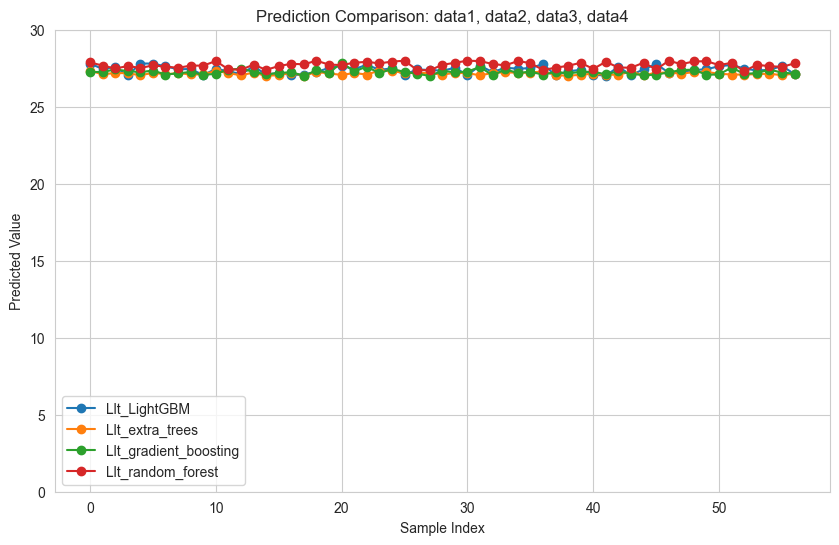

In [217]:
inp = input_processing(res.X)
validation, plus_inp = plus_input_processing(inp)
np_inp = np.array(plus_inp)

data1 = models["Llt_LightGBM"].predict(np_inp)
data2 = models["Llt_extra_trees"].predict(np_inp)
data3 = models["Llt_gradient_boosting"].predict(np_inp)
data4 = models["Llt_random_forest"].predict(np_inp)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(data1, label='Llt_LightGBM', marker='o')
plt.plot(data2, label='Llt_extra_trees', marker='o')
plt.plot(data3, label='Llt_gradient_boosting', marker='o')
plt.plot(data4, label='Llt_random_forest', marker='o')
plt.title("Prediction Comparison: data1, data2, data3, data4")
plt.xlabel("Sample Index")
plt.ylabel("Predicted Value")
plt.legend()
plt.grid(True)
plt.ylim([0,30])
plt.show()

In [ ]:
plt_scatter()

array([[ 9, 33, 72, ..., 78, 43, 69],
       [ 9, 29, 72, ..., 83, 43, 68],
       [ 9, 33, 72, ..., 82, 47, 68],
       ...,
       [ 9, 30, 71, ..., 79, 44, 69],
       [ 9, 32, 72, ..., 83, 41, 67],
       [ 9, 32, 72, ..., 77, 43, 67]], shape=(63, 21))

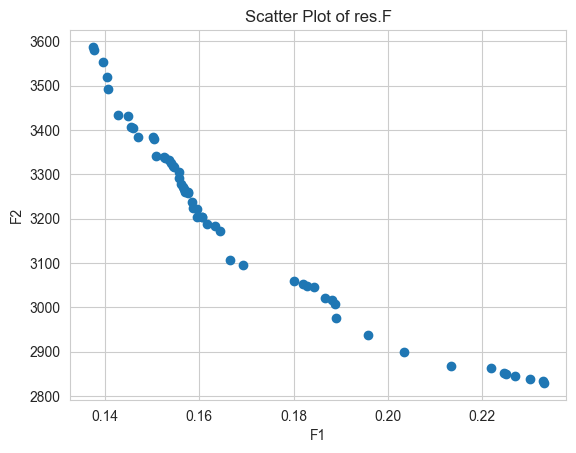

In [218]:

import matplotlib.pyplot as plt

plt.scatter(res.F[:, 0], res.F[:, 1])
plt.xlabel("F1")
plt.ylabel("F2")
plt.title("Scatter Plot of res.F")
plt.show()

In [ ]:
      temp = models["temp_max_core"].predict([np_inp])[0]
        g.append(temp - 100)


        g.append(height - 160)
        g.append(height_cp - 180)
        g.append(length - 250)

        g.append(20 - inp["mold_thick"])
        g.append(9.525 - inp["N1_coil_diameter"])
        g.append(9.525 - inp["N2_coil_diameter"])
        g.append(20 - inp["N1_space_w"])
        g.append(20 - inp["N1_space_l"])
        g.append(20 - inp["h1_gap"])

        g.append(B_mean_leg_left - 0.3)
        g.append(B_mean_leg_right - 0.3)


In [ ]:

def compute_efficiency(inp):

    np_inp = np.array(list(inp.values()))

    winding_loss1 = models["P_winding1"].predict([np_inp])[0]  # 배열에서 스칼라 값 추출
    Lmt = models["Lmt"].predict([np_inp])[0]
    V = 1000
    Im = V/2/3.141592/30e+3/(Lmt*1e-6)
    winding_loss1 = winding_loss1 * ((130+Im)**2 / (130**2))


    winding_loss2 = models["P_winding2"].predict([np_inp])[0]
    core_loss = models["P_core"].predict([np_inp])[0]
    total_loss = winding_loss1 + winding_loss2 + core_loss
    eff = (100e+3) / (100e+3 + total_loss) 

    return eff

def compute_area(inp):

    N1_layer = inp["N1_layer"]
    N2_layer = inp["N2_layer"]
    w1 = inp["w1"]
    l1 = inp["l1"]
    l2 = inp["l2"]
    h1 = inp["h1"]
    N1_layer_gap = inp["N1_layer_gap"]
    N2_layer_gap = inp["N2_layer_gap"]

    N1_space_w = inp["N1_space_w"]
    N1_space_l = inp["N1_space_l"]
    N2_space_w = inp["N2_space_w"]
    N2_space_l = inp["N2_space_l"]

    N1_coil_diameter = inp["N1_coil_diameter"]
    N2_coil_diameter = inp["N2_coil_diameter"]

    mold_thick = inp["mold_thick"]
    cold_plate_z1 = inp["cold_plate_z1"]

    width1 = w1 + 2*N1_space_w + ((2*N1_layer)*N1_coil_diameter) + ((2*(N1_layer-1))*N1_layer_gap) + 2*mold_thick
    width2 = w1 + 2*N2_space_w + ((2*N2_layer)*N2_coil_diameter) + ((2*(N2_layer-1))*N2_layer_gap) + 2*mold_thick
    width = max(width1, width2)

    length = 2*l1 + l2 + N1_space_l + N2_space_l + (N1_layer)*N1_coil_diameter + (N1_layer-1)*N1_layer_gap + (N2_layer)*N2_coil_diameter + (N2_layer-1)*N2_layer_gap + 1*mold_thick

    height = 2*l1 + h1
    height_cp = height + 2*cold_plate_z1

    area = length * width
    volume = length * width * height

    return width, length, height, height_cp, area, volume


# ======================================
# 문제 클래스 정의
# ======================================

# N1, N2, N1_layer, N2_layer, per, w1, l1, l2_gap, h1, N1_height_ratio, 
# N1_fill_factor, N2_height_ratio, N2_fill_factor, N1_space_w, N1_space_h, N2_space_w, N2_space_h, N1_layer_gap, N2_layer_gap, N1_offset_ratio, 
# N2_offset_ratio, cold_plate_x, cold_plate_y, cold_plate_z1, cold_plate_z2, mold_thick, thermal_conductivity

class TransformerProblem(ElementwiseProblem):
    def __init__(self):
        # DEAP과 동일한 하한/상한 (정수형)
        #xl = np.array([ 4,  5,  1,  1, 3000, 1000, 150,  50,  500, 40, 60, 40, 60,  30,  30,  30,  30,  10,  10, -80, -80,   0,   0,  0, 100, 100,  20], dtype=int)
        #xu = np.array([10, 10,  2,  2, 3000, 3500, 400, 500, 1500, 95, 95, 95, 95, 300, 300, 300, 300, 100, 100,  80,  80, 300, 300, 50, 500, 400, 200], dtype=int)
        xl = np.array([ 4,  1,  1, 3000, 1000, 150,  50,  500, 40, 60, 40, 60,  30,  30,  30,  30,  10,  10, -80, -80,   0,   0, 100,  0, 200,  40], dtype=int)
        xu = np.array([10,  2,  2, 3000, 3500, 400, 500, 1500, 95, 95, 95, 95, 300, 300, 300, 300, 100, 100,  80,  80, 300, 300, 300, 10, 400,  40], dtype=int)
        # 제약식이 11개이므로 n_ieq_constr=11
        super().__init__(n_var=26,
                         n_obj=2,
                         n_ieq_constr=14,
                         xl=xl,
                         xu=xu,
                         type_var=int)

    def _evaluate(self, x, out, *args, **kwargs):
        # x는 정수 배열 [x1, x2, ..., x14]
        inp = input_processing(x)
        np_inp = np.array(list(inp.values()))

        # 목적 함수 계산
        width, length, height, height_cp, area, volume = compute_area(inp)
        f1 = volume
        f2 = compute_efficiency(inp)
        

        # 제약식 g_i(x) ≤ 0 으로 변환
        g = []
        Llt = models["Llt"].predict([np_inp])[0]  # 배열에서 스칼라 값 추출
        B_mean_leg_left = models["B_mean_leg_left"].predict([np_inp])[0]
        B_mean_leg_right = models["B_mean_leg_right"].predict([np_inp])[0]
        g.append(31.5 - Llt)   # Llt ≥ 19.5
        g.append(Llt - 32.5)   # Llt ≤ 20.5

        temp = models["temp_max_core"].predict([np_inp])[0]
        g.append(temp - 100)


        g.append(height - 160)
        g.append(height_cp - 180)
        g.append(length - 250)

        g.append(20 - inp["mold_thick"])
        g.append(9.525 - inp["N1_coil_diameter"])
        g.append(9.525 - inp["N2_coil_diameter"])
        g.append(20 - inp["N1_space_w"])
        g.append(20 - inp["N1_space_l"])
        g.append(20 - inp["h1_gap"])

        g.append(B_mean_leg_left - 0.3)
        g.append(B_mean_leg_right - 0.3)




        out["F"] = np.array([f1, -f2])  # numpy 배열로 변환
        out["G"] = np.array(g, dtype=float)


# ======================================
# 실행 함수 정의
# ======================================
def run_nsga2(seed):
    np.random.seed(seed)
    random.seed(seed)

    algorithm = NSGA2(
        pop_size=MU,
        sampling=IntegerRandomSampling(),
        crossover=SBX(prob=CXPB, eta=15, repair=RoundingRepair()),
        mutation=PM(eta=20, repair=RoundingRepair()),
        eliminate_duplicates=True
    )

    return minimize(
        problem=TransformerProblem(),
        algorithm=algorithm,
        termination=('n_gen', NGEN),
        seed=seed,
        verbose=True
    )


def build_df_from_result(res):
    pareto_X = res.X.astype(int)
    rows = []
    for x in pareto_X:
        inp = input_processing(x)
        np_inp = np.array(list(inp.values()))
        width, length, height, height_cp, area, volume = compute_area(inp)
        winding_loss1 = models["P_winding1"].predict([np_inp])[0]
        V = 1000
        Lmt = models["Lmt"].predict([np_inp])[0]
        Im = V/2/3.141592/30e+3/(Lmt*1e-6)
        winding_loss1_130 = winding_loss1 * ((130+Im)**2 / (130**2))
        winding_loss2 = models["P_winding2"].predict([np_inp])[0]
        core_loss = models["P_core"].predict([np_inp])[0]
        total_loss = winding_loss1 + winding_loss2 + core_loss
        total_loss_130 = winding_loss1_130 + winding_loss2 + core_loss
        eff = (100e+3) / (100e+3 + total_loss) * 100
        eff_130 = (100e+3) / (100e+3 + total_loss_130) * 100
        
        Llt = models["Llt"].predict([np_inp])[0]
        temp = models["temp_max_core"].predict([np_inp])[0]
        B_mean_leg_left = models["B_mean_leg_left"].predict([np_inp])[0]
        B_mean_leg_right = models["B_mean_leg_right"].predict([np_inp])[0]

        row = dict(zip(feature_names, np_inp))
        row.update({
            "area": area / 100,  # mm^2 to cm^2
            "volume": volume / 1e6,  # mm^3 to L
            "eff": eff,
            "eff_130": eff_130,
            "width": width,
            "length": length,
            "height": height,
            "height_cp": height_cp,
            "Lmt": Lmt,
            "Llt": Llt,
            "winding_loss1": winding_loss1,
            "winding_loss1_130": winding_loss1_130,
            "winding_loss2": winding_loss2,
            "core_loss": core_loss,
            "total_loss": total_loss,
            "total_loss_130": total_loss_130,
            "temp": temp,
            "B_mean_leg_left": B_mean_leg_left,
            "B_mean_leg_right": B_mean_leg_right
        })
        rows.append(row)

    return pd.DataFrame(rows)


# ======================================
# 메인 실행부
# ======================================
MU, NGEN = 100, 1000
CXPB, MUTPB = 0.7, 0.3
NUM_ITRS = 1000

feature_names = [
    "N1", "N2", "N1_layer", "N2_layer", "per", "w1", "l1", "l2", "l2_gap", "h1",
    "h1_gap", "h2_gap", "N1_height_ratio", "N1_fill_factor", "N1_coil_diameter",
    "N1_coil_zgap", "N2_height_ratio", "N2_fill_factor", "N2_coil_diameter",
    "N2_coil_zgap", "N1_space_w", "N1_space_l", "N2_space_w", "N2_space_l",
    "N1_layer_gap", "N2_layer_gap", "N1_offset_ratio", "N2_offset_ratio", "N1_offset", "N2_offset",
    "cold_plate_x", "cold_plate_y", "cold_plate_z1", "cold_plate_z2",
    "mold_thick", "thermal_conductivity"
]

# 이전 결과 파일이 있으면 로드
pareto_file = 'pareto_front.csv'
if os.path.exists(pareto_file):
    previous_pareto = pd.read_csv(pareto_file)
else:
    previous_pareto = pd.DataFrame()

# 루프 카운터 파일 로드 또는 생성
loop_counter_file = 'loop_counter.txt'
if os.path.exists(loop_counter_file):
    with open(loop_counter_file, 'r') as f:
        loop_counter = int(f.read().strip())
else:
    loop_counter = 0

all_results = []
for itr in range(NUM_ITRS):
    print(f"Running NSGA-II {itr+1} / {NUM_ITRS}")
    seed = np.random.randint(0, 1000000)
    res = run_nsga2(seed)
    
    try:
        df = build_df_from_result(res)
        if df is not None:
            all_results.append(df)
            
            # 현재까지의 결과와 이전 파레토 프론트 결합
            df_current = pd.concat(all_results + [previous_pareto], ignore_index=True)
            F = df_current[["volume", "eff"]].to_numpy()
            F[:, 1] = -F[:, 1]  # 효율 최대화 → 부호 반전

            # Non-dominated sorting
            nds = NonDominatedSorting().do(F, only_non_dominated_front=True)
            df_pareto = df_current.iloc[nds].copy()
            df_pareto["eff"] = -F[nds, 1]  # 다시 양수로 되돌리기
            df_pareto = df_pareto.sort_values(by="eff", ascending=False).reset_index(drop=True)
            
            # 현재 파레토 프론트 저장
            df_pareto.to_csv(pareto_file, index=False)
            
            # 루프 카운터 증가 및 저장
            loop_counter += 1
            with open(loop_counter_file, 'w') as f:
                f.write(str(loop_counter))
            
            # 10번마다 백업 파일 생성
            if loop_counter % 10 == 0 or loop_counter == 1:
                backup_file = f'pareto_front_backup_{loop_counter}.csv'
                df_pareto.to_csv(backup_file, index=False)
                print(f"Backup created: {backup_file}")
                
            print(f"Iteration {itr+1} Pareto front saved (Total loops: {loop_counter})")
    except AttributeError as e:
        print(f"Iteration {itr+1} failed: {str(e)}")
        continue
    except Exception as e:
        print(f"Unexpected error in iteration {itr+1}: {str(e)}")
        continue

# 최종 결과 출력
if 'df_pareto' in locals():
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    print("Final Pareto front:")
    print(df_pareto)
else:
    print("No valid results found")


In [28]:
import pandas as pd

# simulation_result.csv 파일을 읽어오고, 1번째(인덱스 0)부터 49번째(인덱스 48) 컬럼까지만 가져온다
csv_path = os.path.join(os.getcwd(), "simulation_results.csv")
simulation_df = pd.read_csv(csv_path, usecols=range(49))

valid_mask = ~simulation_df.isna().any(axis=1)   # NaN 없는 행만 True
simulation_df_pred = simulation_df.loc[valid_mask].copy()

pred_df = pd.DataFrame(index=simulation_df.index)

pred_df.loc[valid_mask, "Llt_LightGBM"] = models["Llt_LightGBM"].predict(simulation_df_pred)
pred_df.loc[valid_mask, "Llt_random_forest"] = models["Llt_random_forest"].predict(simulation_df_pred)
pred_df.loc[valid_mask, "Llt_extra_trees"] = models["Llt_extra_trees"].predict(simulation_df_pred)
pred_df.loc[valid_mask, "Llt_gradient_boosting"] = models["Llt_gradient_boosting"].predict(simulation_df_pred)

print("제외된 행 수:", (~valid_mask).sum())
display(pred_df.head())

제외된 행 수: 1


,Llt_LightGBM,Llt_random_forest,Llt_extra_trees,Llt_gradient_boosting
0,4.285537,3.814693,3.305557,4.373250
1,3.195380,2.676582,2.734463,3.369127
2,9.291792,9.826710,8.754061,9.400537
3,1.978051,2.412623,2.356361,1.921440
4,1.491774,1.721824,2.055597,1.609170


,Llt_LightGBM,Llt_random_forest,Llt_extra_trees,Llt_gradient_boosting
0,4.285537,3.814693,3.305557,4.373250
1,3.195380,2.676582,2.734463,3.369127
2,9.291792,9.826710,8.754061,9.400537
3,1.978051,2.412623,2.356361,1.921440
4,1.491774,1.721824,2.055597,1.609170


,mean,std,min,25%,50%,75%,max
Llt_LightGBM,13.523657,10.148948,0.622847,5.891934,10.331514,18.358083,57.562964
Llt_random_forest,12.918751,8.676791,1.428860,5.966519,10.319882,17.969519,34.826582
Llt_extra_trees,12.924820,8.784413,1.707223,5.914025,10.253386,17.876671,35.164932
Llt_gradient_boosting,13.603329,10.448104,0.592576,5.848086,10.331945,18.379964,66.548644


,model_a,model_b,MAE_between_preds,R2_between_preds
2,Llt_LightGBM,Llt_gradient_boosting,0.575227,0.990608
3,Llt_random_forest,Llt_extra_trees,0.618459,0.987744
0,Llt_LightGBM,Llt_random_forest,1.213735,0.940017
1,Llt_LightGBM,Llt_extra_trees,1.261132,0.943406
4,Llt_random_forest,Llt_gradient_boosting,1.334038,0.880271
5,Llt_extra_trees,Llt_gradient_boosting,1.371585,0.889787


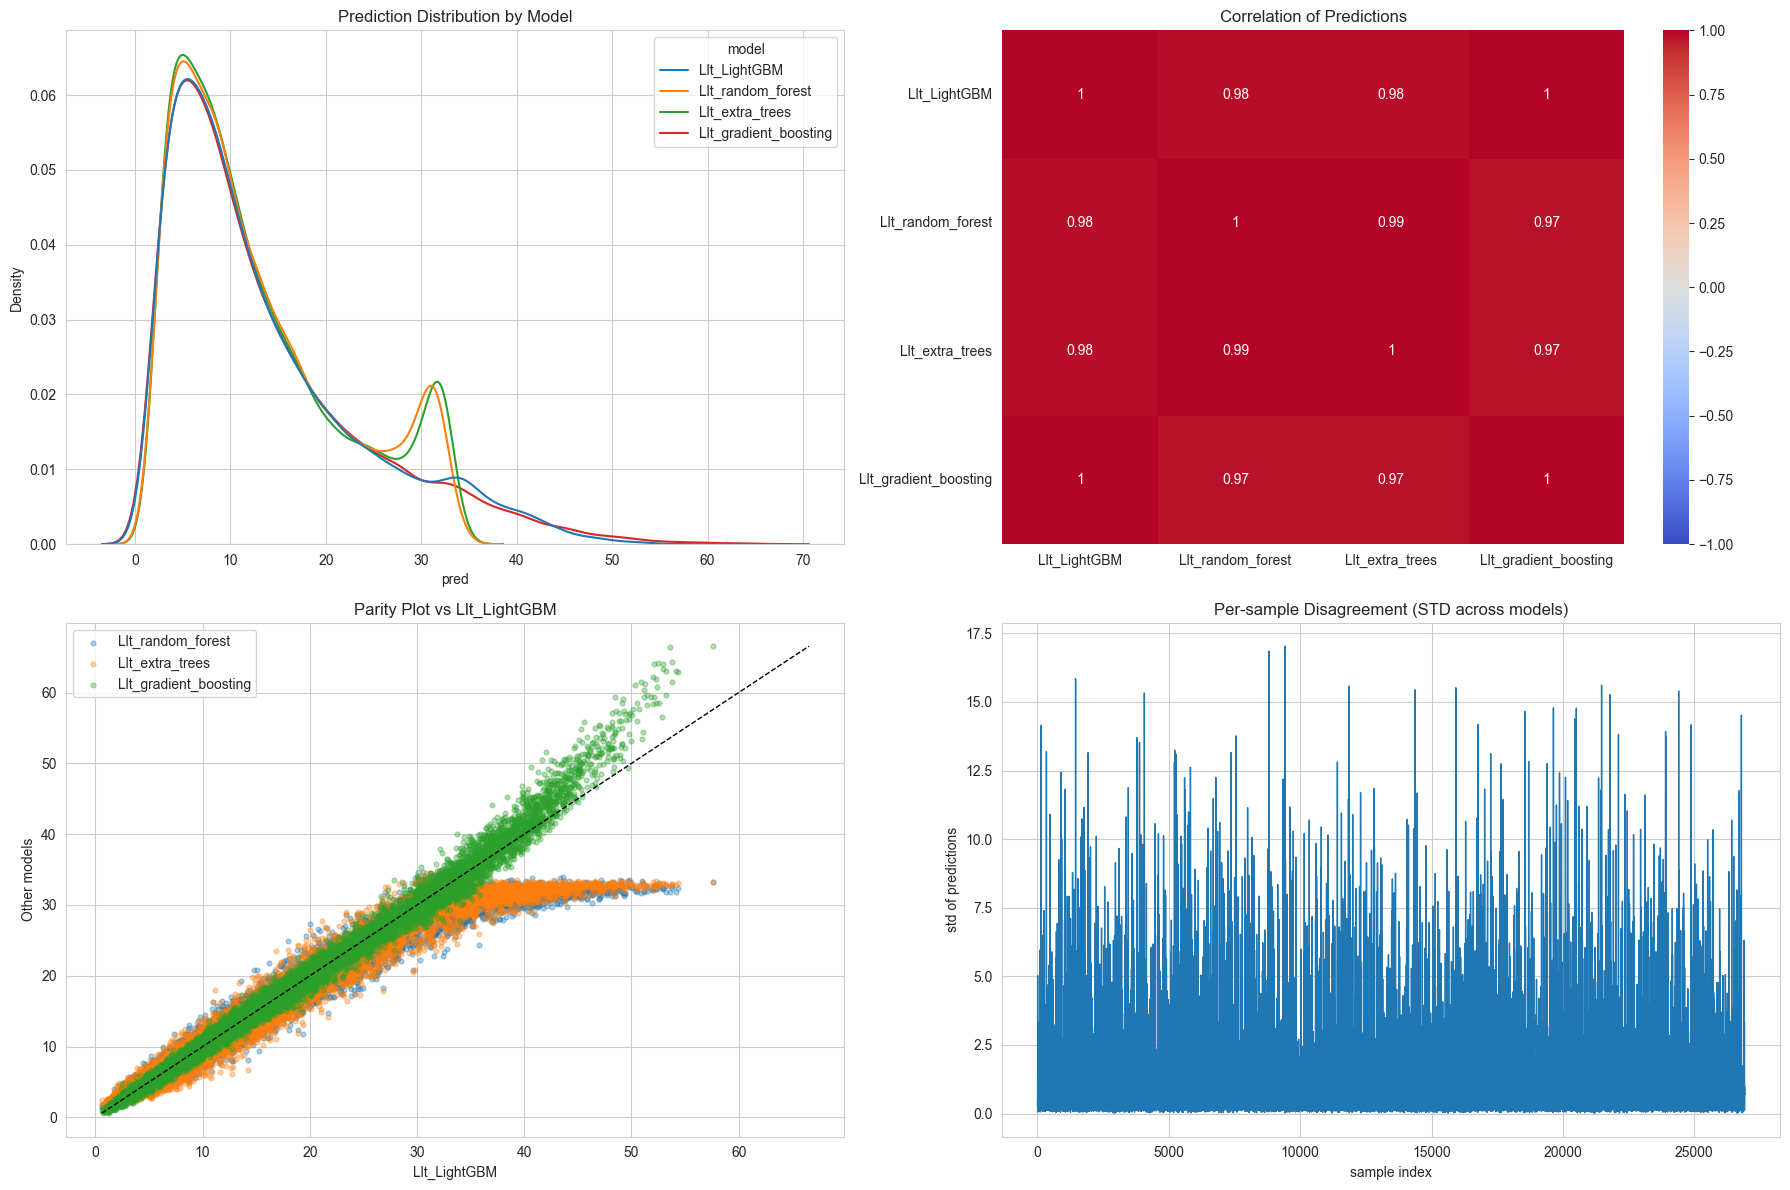

In [29]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.metrics import mean_absolute_error, r2_score

# 1) 예측값 모으기
model_keys = [
    "Llt_LightGBM",
    "Llt_random_forest",
    "Llt_extra_trees",
    "Llt_gradient_boosting",
]

pred_df = pd.DataFrame({
    k: np.asarray(models[k].predict(simulation_df_pred)).ravel()
    for k in model_keys
})

display(pred_df.head())

# 2) 요약 통계
summary = pred_df.describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
display(summary)

# 3) 모델 간 pairwise 차이 수치
rows = []
for a, b in combinations(model_keys, 2):
    rows.append({
        "model_a": a,
        "model_b": b,
        "MAE_between_preds": mean_absolute_error(pred_df[a], pred_df[b]),
        "R2_between_preds": r2_score(pred_df[a], pred_df[b]),
    })
pair_metrics = pd.DataFrame(rows).sort_values("MAE_between_preds")
display(pair_metrics)

# 4) 시각화
sns.set_style("whitegrid")
fig = plt.figure(figsize=(18, 12))

# (a) 분포 비교
ax1 = plt.subplot(2, 2, 1)
long_df = pred_df.melt(var_name="model", value_name="pred")
sns.kdeplot(data=long_df, x="pred", hue="model", common_norm=False, fill=False, ax=ax1)
ax1.set_title("Prediction Distribution by Model")

# (b) 상관 히트맵
ax2 = plt.subplot(2, 2, 2)
sns.heatmap(pred_df.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=ax2)
ax2.set_title("Correlation of Predictions")

# (c) LightGBM 기준 1:1 산점도
base = "Llt_LightGBM"
ax3 = plt.subplot(2, 2, 3)
for m in model_keys:
    if m == base:
        continue
    ax3.scatter(pred_df[base], pred_df[m], s=12, alpha=0.35, label=m)
mn = pred_df.min().min()
mx = pred_df.max().max()
ax3.plot([mn, mx], [mn, mx], "k--", linewidth=1)
ax3.set_xlabel(base)
ax3.set_ylabel("Other models")
ax3.set_title("Parity Plot vs Llt_LightGBM")
ax3.legend()

# (d) 샘플별 불일치(표준편차)
ax4 = plt.subplot(2, 2, 4)
disagree = pred_df.std(axis=1)
ax4.plot(disagree.values, linewidth=1)
ax4.set_title("Per-sample Disagreement (STD across models)")
ax4.set_xlabel("sample index")
ax4.set_ylabel("std of predictions")

plt.tight_layout()
plt.show()

In [3]:
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

In [3]:
import numpy as np


def calculate_coil_parameter(N, N_layer, h1, height_ratio, fill_factor):
    height = h1 * height_ratio
    effective_height = height * fill_factor

    if N_layer == 1:
        effective_N = N
    elif N_layer == 2:
        effective_N = math.ceil(N / 2)
    else:
        effective_N = N 

    if effective_N == 0:
        return 0, 0

    coil_diameter = effective_height / (effective_N + 1)
    
    if effective_N > 0:
        coil_z_gap = (height - effective_height) / effective_N
    else:
        coil_z_gap = 0

    return coil_diameter, coil_z_gap


def calculate_coil_offset(N, N_layer, h1, height_ratio, offset_ratio) :

    height = h1 * height_ratio
    offset = (h1 - height)/2 * offset_ratio

    return offset


def input_processing(input_vector):

    input_vector = np.array(input_vector)

    # N1, N2, N1_layer, N2_layer, per, w1, l1, l2_gap, h1, N1_height_ratio, 
    # N1_fill_factor, N2_height_ratio, N2_fill_factor, N1_space_w, N1_space_h, N2_space_w, N2_space_h, N1_layer_gap, N2_layer_gap, N1_offset_ratio, 
    # N2_offset_ratio, cold_plate_x, cold_plate_y, cold_plate_z1, cold_plate_z2, mold_thick, thermal_conductivity

    N1 = input_vector[0]
    N1_layer = input_vector[1]
    N2_layer = input_vector[2]

    per = input_vector[3]

    w1 = input_vector[4] / 10
    l1 = input_vector[5] / 10
    l2_gap = input_vector[6] / 10
    h1 = input_vector[7] / 10

    N1_height_ratio = input_vector[8] / 100
    N1_fill_factor = input_vector[9] / 100
    N2_height_ratio = input_vector[10] / 100
    N2_fill_factor = input_vector[11] / 100

    N1_space_w = input_vector[12] / 10
    N1_space_l = input_vector[13] / 10
    N2_space_w = input_vector[14] / 10
    N2_space_l = input_vector[15] / 10
    N1_layer_gap = input_vector[16] / 10
    N2_layer_gap = input_vector[17] / 10

    N1_offset_ratio = input_vector[18] / 100
    N2_offset_ratio = input_vector[19] / 100

    cold_plate_x = input_vector[20] / 10    
    cold_plate_y = input_vector[21] / 10
    cold_plate_z1 = input_vector[22] / 10
    cold_plate_z2 = input_vector[23] / 100

    mold_thick = input_vector[24] / 10
    thermal_conductivity = input_vector[25] / 100

    N1_coil_diameter, N1_coil_zgap = calculate_coil_parameter(N1, N1_layer, h1, N1_height_ratio, N1_fill_factor)
    N2_coil_diameter, N2_coil_zgap = calculate_coil_parameter(N1, N2_layer, h1, N2_height_ratio, N2_fill_factor)

    N1_offset = calculate_coil_offset(N1, N1_layer, h1, N1_height_ratio, N1_offset_ratio)
    N2_offset = calculate_coil_offset(N1, N2_layer, h1, N2_height_ratio, N2_offset_ratio)

    h1_gap = (h1 - h1*N1_height_ratio)/2 - abs(N1_offset)
    h2_gap = (h1 - h1*N2_height_ratio)/2 - abs(N2_offset)

    l2_lower = N1_layer*N1_coil_diameter + N2_layer*N2_coil_diameter + (N1_layer-1)*N1_layer_gap + (N2_layer-1)*N2_layer_gap + N1_space_l + N2_space_l + mold_thick
    l2 = l2_lower + l2_gap

    parameter = {
        "N1": N1,
        "N2": N1,
        "N1_layer": N1_layer,
        "N2_layer": N2_layer,

        "per": per,

        "w1": w1,
        "l1": l1,
        "l2": l2,
        "l2_gap": l2_gap,
        "h1": h1,
        "h1_gap": h1_gap,
        "h2_gap": h2_gap,

        "N1_height_ratio": N1_height_ratio,
        "N1_fill_factor": N1_fill_factor,
        "N1_coil_diameter": N1_coil_diameter,
        "N1_coil_zgap": N1_coil_zgap,
        "N2_height_ratio": N2_height_ratio,
        "N2_fill_factor": N2_fill_factor,
        "N2_coil_diameter": N2_coil_diameter,
        "N2_coil_zgap": N2_coil_zgap,

        "N1_space_w": N1_space_w,
        "N1_space_l": N1_space_l,
        "N2_space_w": N2_space_w,
        "N2_space_l": N2_space_l,
        "N1_layer_gap": N1_layer_gap,
        "N2_layer_gap": N2_layer_gap,

        "N1_offset_ratio": N1_offset_ratio,
        "N2_offset_ratio": N2_offset_ratio,
        "N1_offset": N1_offset,
        "N2_offset": N2_offset,

        "cold_plate_x": cold_plate_x,
        "cold_plate_y": cold_plate_y,
        "cold_plate_z1": cold_plate_z1,
        "cold_plate_z2": cold_plate_z2,

        "mold_thick": mold_thick,
        "thermal_conductivity": thermal_conductivity
    }

    return parameter


In [1]:
parameter = input_processing([1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7])

# dictionary를 numpy array로 변환
parameter_array = np.array(list(parameter.values()))
models["Llt"].predict([parameter_array])


parameter["N1"]

NameError: name 'input_processing' is not defined

In [ ]:
# roop

import numpy as np
import pandas as pd
import random
import math
import os

from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.repair.rounding import RoundingRepair
from pymoo.optimize import minimize
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting


def compute_efficiency(inp):

    np_inp = np.array(list(inp.values()))

    winding_loss1 = models["P_winding1"].predict([np_inp])[0]  # 배열에서 스칼라 값 추출
    Lmt = models["Lmt"].predict([np_inp])[0]
    V = 1000
    Im = V/2/3.141592/30e+3/(Lmt*1e-6)
    winding_loss1 = winding_loss1 * ((130+Im)**2 / (130**2))


    winding_loss2 = models["P_winding2"].predict([np_inp])[0]
    core_loss = models["P_core"].predict([np_inp])[0]
    total_loss = winding_loss1 + winding_loss2 + core_loss
    eff = (100e+3) / (100e+3 + total_loss) 

    return eff

def compute_area(inp):

    N1_layer = inp["N1_layer"]
    N2_layer = inp["N2_layer"]
    w1 = inp["w1"]
    l1 = inp["l1"]
    l2 = inp["l2"]
    h1 = inp["h1"]
    N1_layer_gap = inp["N1_layer_gap"]
    N2_layer_gap = inp["N2_layer_gap"]

    N1_space_w = inp["N1_space_w"]
    N1_space_l = inp["N1_space_l"]
    N2_space_w = inp["N2_space_w"]
    N2_space_l = inp["N2_space_l"]

    N1_coil_diameter = inp["N1_coil_diameter"]
    N2_coil_diameter = inp["N2_coil_diameter"]

    mold_thick = inp["mold_thick"]
    cold_plate_z1 = inp["cold_plate_z1"]

    width1 = w1 + 2*N1_space_w + ((2*N1_layer)*N1_coil_diameter) + ((2*(N1_layer-1))*N1_layer_gap) + 2*mold_thick
    width2 = w1 + 2*N2_space_w + ((2*N2_layer)*N2_coil_diameter) + ((2*(N2_layer-1))*N2_layer_gap) + 2*mold_thick
    width = max(width1, width2)

    length = 2*l1 + l2 + N1_space_l + N2_space_l + (N1_layer)*N1_coil_diameter + (N1_layer-1)*N1_layer_gap + (N2_layer)*N2_coil_diameter + (N2_layer-1)*N2_layer_gap + 1*mold_thick

    height = 2*l1 + h1
    height_cp = height + 2*cold_plate_z1

    area = length * width
    volume = length * width * height

    return width, length, height, height_cp, area, volume


# ======================================
# 문제 클래스 정의
# ======================================

# N1, N2, N1_layer, N2_layer, per, w1, l1, l2_gap, h1, N1_height_ratio, 
# N1_fill_factor, N2_height_ratio, N2_fill_factor, N1_space_w, N1_space_h, N2_space_w, N2_space_h, N1_layer_gap, N2_layer_gap, N1_offset_ratio, 
# N2_offset_ratio, cold_plate_x, cold_plate_y, cold_plate_z1, cold_plate_z2, mold_thick, thermal_conductivity

class TransformerProblem(ElementwiseProblem):
    def __init__(self):
        # DEAP과 동일한 하한/상한 (정수형)
        #xl = np.array([ 4,  5,  1,  1, 3000, 1000, 150,  50,  500, 40, 60, 40, 60,  30,  30,  30,  30,  10,  10, -80, -80,   0,   0,  0, 100, 100,  20], dtype=int)
        #xu = np.array([10, 10,  2,  2, 3000, 3500, 400, 500, 1500, 95, 95, 95, 95, 300, 300, 300, 300, 100, 100,  80,  80, 300, 300, 50, 500, 400, 200], dtype=int)
        xl = np.array([ 4,  1,  1, 3000, 1000, 150,  50,  500, 40, 60, 40, 60,  30,  30,  30,  30,  10,  10, -80, -80,   0,   0, 100,  0, 200,  40], dtype=int)
        xu = np.array([10,  2,  2, 3000, 3500, 400, 500, 1500, 95, 95, 95, 95, 300, 300, 300, 300, 100, 100,  80,  80, 300, 300, 300, 10, 400,  40], dtype=int)
        # 제약식이 11개이므로 n_ieq_constr=11
        super().__init__(n_var=26,
                         n_obj=2,
                         n_ieq_constr=14,
                         xl=xl,
                         xu=xu,
                         type_var=int)

    def _evaluate(self, x, out, *args, **kwargs):
        # x는 정수 배열 [x1, x2, ..., x14]
        inp = input_processing(x)
        np_inp = np.array(list(inp.values()))

        # 목적 함수 계산
        width, length, height, height_cp, area, volume = compute_area(inp)
        f1 = volume
        f2 = compute_efficiency(inp)
        

        # 제약식 g_i(x) ≤ 0 으로 변환
        g = []
        Llt = models["Llt"].predict([np_inp])[0]  # 배열에서 스칼라 값 추출
        B_mean_leg_left = models["B_mean_leg_left"].predict([np_inp])[0]
        B_mean_leg_right = models["B_mean_leg_right"].predict([np_inp])[0]
        g.append(31.5 - Llt)   # Llt ≥ 19.5
        g.append(Llt - 32.5)   # Llt ≤ 20.5

        temp = models["temp_max_core"].predict([np_inp])[0]
        g.append(temp - 100)


        g.append(height - 160)
        g.append(height_cp - 180)
        g.append(length - 250)

        g.append(20 - inp["mold_thick"])
        g.append(9.525 - inp["N1_coil_diameter"])
        g.append(9.525 - inp["N2_coil_diameter"])
        g.append(20 - inp["N1_space_w"])
        g.append(20 - inp["N1_space_l"])
        g.append(20 - inp["h1_gap"])

        g.append(B_mean_leg_left - 0.3)
        g.append(B_mean_leg_right - 0.3)




        out["F"] = np.array([f1, -f2])  # numpy 배열로 변환
        out["G"] = np.array(g, dtype=float)


# ======================================
# 실행 함수 정의
# ======================================
def run_nsga2(seed):
    np.random.seed(seed)
    random.seed(seed)

    algorithm = NSGA2(
        pop_size=MU,
        sampling=IntegerRandomSampling(),
        crossover=SBX(prob=CXPB, eta=15, repair=RoundingRepair()),
        mutation=PM(eta=20, repair=RoundingRepair()),
        eliminate_duplicates=True
    )

    return minimize(
        problem=TransformerProblem(),
        algorithm=algorithm,
        termination=('n_gen', NGEN),
        seed=seed,
        verbose=True
    )


def build_df_from_result(res):
    pareto_X = res.X.astype(int)
    rows = []
    for x in pareto_X:
        inp = input_processing(x)
        np_inp = np.array(list(inp.values()))
        width, length, height, height_cp, area, volume = compute_area(inp)
        winding_loss1 = models["P_winding1"].predict([np_inp])[0]
        V = 1000
        Lmt = models["Lmt"].predict([np_inp])[0]
        Im = V/2/3.141592/30e+3/(Lmt*1e-6)
        winding_loss1_130 = winding_loss1 * ((130+Im)**2 / (130**2))
        winding_loss2 = models["P_winding2"].predict([np_inp])[0]
        core_loss = models["P_core"].predict([np_inp])[0]
        total_loss = winding_loss1 + winding_loss2 + core_loss
        total_loss_130 = winding_loss1_130 + winding_loss2 + core_loss
        eff = (100e+3) / (100e+3 + total_loss) * 100
        eff_130 = (100e+3) / (100e+3 + total_loss_130) * 100
        
        Llt = models["Llt"].predict([np_inp])[0]
        temp = models["temp_max_core"].predict([np_inp])[0]
        B_mean_leg_left = models["B_mean_leg_left"].predict([np_inp])[0]
        B_mean_leg_right = models["B_mean_leg_right"].predict([np_inp])[0]

        row = dict(zip(feature_names, np_inp))
        row.update({
            "area": area / 100,  # mm^2 to cm^2
            "volume": volume / 1e6,  # mm^3 to L
            "eff": eff,
            "eff_130": eff_130,
            "width": width,
            "length": length,
            "height": height,
            "height_cp": height_cp,
            "Lmt": Lmt,
            "Llt": Llt,
            "winding_loss1": winding_loss1,
            "winding_loss1_130": winding_loss1_130,
            "winding_loss2": winding_loss2,
            "core_loss": core_loss,
            "total_loss": total_loss,
            "total_loss_130": total_loss_130,
            "temp": temp,
            "B_mean_leg_left": B_mean_leg_left,
            "B_mean_leg_right": B_mean_leg_right
        })
        rows.append(row)

    return pd.DataFrame(rows)


# ======================================
# 메인 실행부
# ======================================
MU, NGEN = 100, 1000
CXPB, MUTPB = 0.7, 0.3
NUM_ITRS = 1000

feature_names = [
    "N1", "N2", "N1_layer", "N2_layer", "per", "w1", "l1", "l2", "l2_gap", "h1",
    "h1_gap", "h2_gap", "N1_height_ratio", "N1_fill_factor", "N1_coil_diameter",
    "N1_coil_zgap", "N2_height_ratio", "N2_fill_factor", "N2_coil_diameter",
    "N2_coil_zgap", "N1_space_w", "N1_space_l", "N2_space_w", "N2_space_l",
    "N1_layer_gap", "N2_layer_gap", "N1_offset_ratio", "N2_offset_ratio", "N1_offset", "N2_offset",
    "cold_plate_x", "cold_plate_y", "cold_plate_z1", "cold_plate_z2",
    "mold_thick", "thermal_conductivity"
]

# 이전 결과 파일이 있으면 로드
pareto_file = 'pareto_front.csv'
if os.path.exists(pareto_file):
    previous_pareto = pd.read_csv(pareto_file)
else:
    previous_pareto = pd.DataFrame()

# 루프 카운터 파일 로드 또는 생성
loop_counter_file = 'loop_counter.txt'
if os.path.exists(loop_counter_file):
    with open(loop_counter_file, 'r') as f:
        loop_counter = int(f.read().strip())
else:
    loop_counter = 0

all_results = []
for itr in range(NUM_ITRS):
    print(f"Running NSGA-II {itr+1} / {NUM_ITRS}")
    seed = np.random.randint(0, 1000000)
    res = run_nsga2(seed)
    
    try:
        df = build_df_from_result(res)
        if df is not None:
            all_results.append(df)
            
            # 현재까지의 결과와 이전 파레토 프론트 결합
            df_current = pd.concat(all_results + [previous_pareto], ignore_index=True)
            F = df_current[["volume", "eff"]].to_numpy()
            F[:, 1] = -F[:, 1]  # 효율 최대화 → 부호 반전

            # Non-dominated sorting
            nds = NonDominatedSorting().do(F, only_non_dominated_front=True)
            df_pareto = df_current.iloc[nds].copy()
            df_pareto["eff"] = -F[nds, 1]  # 다시 양수로 되돌리기
            df_pareto = df_pareto.sort_values(by="eff", ascending=False).reset_index(drop=True)
            
            # 현재 파레토 프론트 저장
            df_pareto.to_csv(pareto_file, index=False)
            
            # 루프 카운터 증가 및 저장
            loop_counter += 1
            with open(loop_counter_file, 'w') as f:
                f.write(str(loop_counter))
            
            # 10번마다 백업 파일 생성
            if loop_counter % 10 == 0 or loop_counter == 1:
                backup_file = f'pareto_front_backup_{loop_counter}.csv'
                df_pareto.to_csv(backup_file, index=False)
                print(f"Backup created: {backup_file}")
                
            print(f"Iteration {itr+1} Pareto front saved (Total loops: {loop_counter})")
    except AttributeError as e:
        print(f"Iteration {itr+1} failed: {str(e)}")
        continue
    except Exception as e:
        print(f"Unexpected error in iteration {itr+1}: {str(e)}")
        continue

# 최종 결과 출력
if 'df_pareto' in locals():
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    print("Final Pareto front:")
    print(df_pareto)
else:
    print("No valid results found")


Running NSGA-II 1 / 1000
n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      100 |      1 |  4.601132E+01 |  1.640871E+02 |             - |             -
     2 |      200 |      1 |  2.082100E+01 |  7.368828E+01 |             - |             -
     3 |      300 |      1 |  2.082100E+01 |  5.227437E+01 |             - |             -
     4 |      400 |      1 |  9.5586822198 |  3.858766E+01 |             - |             -
     5 |      500 |      1 |  9.5586822198 |  2.884795E+01 |             - |             -
     6 |      600 |      1 |  7.0644428571 |  2.305158E+01 |             - |             -
     7 |      700 |      1 |  5.4693192812 |  1.805550E+01 |             - |             -
     8 |      800 |      1 |  5.4693192812 |  1.329546E+01 |             - |             -
     9 |      900 |      1 |  5.4693192812 |  9.9382993611 |             - |             -
    10 |     1000 |      1 |  2.4217550000 |  7.2287279776 |     

KeyboardInterrupt: 

In [81]:
import numpy as np
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.repair.rounding import RoundingRepair
from pymoo.optimize import minimize
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
import math
import pandas as pd



def compute_efficiency(inp):

    np_inp = np.array(list(inp.values()))

    winding_loss1 = models["P_winding1"].predict([np_inp])[0]  # 배열에서 스칼라 값 추출
    winding_loss2 = models["P_winding2"].predict([np_inp])[0]
    core_loss = models["P_core"].predict([np_inp])[0]
    total_loss = winding_loss1 + winding_loss2 + core_loss
    eff = (100e+3) / (100e+3 + total_loss) 

    return eff

def compute_area(inp):

    N1_layer = inp["N1_layer"]
    N2_layer = inp["N2_layer"]
    w1 = inp["w1"]
    l1 = inp["l1"]
    l2 = inp["l2"]
    h1 = inp["h1"]
    N1_layer_gap = inp["N1_layer_gap"]
    N2_layer_gap = inp["N2_layer_gap"]

    N1_space_w = inp["N1_space_w"]
    N1_space_l = inp["N1_space_l"]
    N2_space_w = inp["N2_space_w"]
    N2_space_l = inp["N2_space_l"]

    N1_coil_diameter = inp["N1_coil_diameter"]
    N2_coil_diameter = inp["N2_coil_diameter"]

    mold_thick = inp["mold_thick"]
    cold_plate_z1 = inp["cold_plate_z1"]

    width1 = w1 + 2*N1_space_w + ((2*N1_layer)*N1_coil_diameter) + ((2*(N1_layer-1))*N1_layer_gap) + 2*mold_thick
    width2 = w1 + 2*N2_space_w + ((2*N2_layer)*N2_coil_diameter) + ((2*(N2_layer-1))*N2_layer_gap) + 2*mold_thick
    width = max(width1, width2)

    length = 2*l1 + l2 + N1_space_l + N2_space_l + (N1_layer)*N1_coil_diameter + (N1_layer-1)*N1_layer_gap + (N2_layer)*N2_coil_diameter + (N2_layer-1)*N2_layer_gap + 2*mold_thick

    height = 2*l1 + h1
    height_cp = height + 2*cold_plate_z1

    area = length * width
    volume = length * width * height

    return width, length, height, height_cp, area, volume

# N1, N2, N1_layer, N2_layer, per, w1, l1, l2_gap, h1, N1_height_ratio, 
# N1_fill_factor, N2_height_ratio, N2_fill_factor, N1_space_w, N1_space_h, N2_space_w, N2_space_h, N1_layer_gap, N2_layer_gap, N1_offset_ratio, 
# N2_offset_ratio, cold_plate_x, cold_plate_y, cold_plate_z1, cold_plate_z2, mold_thick, thermal_conductivity


class TransformerProblem(ElementwiseProblem):
    def __init__(self):
        # DEAP과 동일한 하한/상한 (정수형)
        #xl = np.array([ 5,  5,  1,  1, 3000, 1000, 150,  50,  500, 40, 60, 40, 60,  30,  30,  30,  30,  10,  10, -80, -80,   0,   0, 100, 100, 100,  20], dtype=int)
        #xu = np.array([10, 10,  2,  2, 3000, 3500, 400, 500, 1500, 95, 95, 95, 95, 300, 300, 300, 300, 100, 100,  80,  80, 300, 300, 500, 500, 400, 200], dtype=int)
        xl = np.array([ 5,  5,  1,  1, 3000, 1000, 150,  50,  500, 40, 60, 40, 60,  30,  30,  30,  30,  10,  10, -80, -80,   0,   0, 100, 100, 200,  40], dtype=int)
        xu = np.array([10, 10,  2,  2, 3000, 3500, 400, 500, 1500, 95, 95, 95, 95, 300, 300, 300, 300, 100, 100,  80,  80, 300, 300, 300, 100, 400,  40], dtype=int)
        # 제약식이 11개이므로 n_ieq_constr=11
        super().__init__(n_var=27,
                         n_obj=2,
                         n_ieq_constr=9,
                         xl=xl,
                         xu=xu,
                         type_var=int)

    def _evaluate(self, x, out, *args, **kwargs):
        # x는 정수 배열 [x1, x2, ..., x14]
        inp = input_processing(x)
        np_inp = np.array(list(inp.values()))

        # 목적 함수 계산
        width, length, height, height_cp, area, volume = compute_area(inp)
        f1 = area
        f2 = compute_efficiency(inp)
        

        # 제약식 g_i(x) ≤ 0 으로 변환
        g = []
        Llt = models["Llt"].predict([np_inp])[0]  # 배열에서 스칼라 값 추출
        g.append(19.5 - Llt)   # Llt ≥ 19.5
        g.append(Llt - 20.5)   # Llt ≤ 20.5

        temp = models["temp_max_core"].predict([np_inp])[0]
        g.append(temp - 100)


        g.append(height - 160)
        g.append(height_cp - 180)
        g.append(length - 250)

        g.append(20 - inp["mold_thick"])
        g.append(9.525 - inp["N1_coil_diameter"])
        g.append(9.525 - inp["N2_coil_diameter"])




        out["F"] = np.array([f1, -f2])  # numpy 배열로 변환
        out["G"] = np.array(g, dtype=float)


if __name__ == "__main__":
    MU, NGEN = 100, 500
    CXPB, MUTPB = 0.7, 0.3

    algorithm = NSGA2(
        pop_size=MU,
        sampling=IntegerRandomSampling(),
        crossover=SBX(prob=CXPB, eta=15, repair=RoundingRepair()),
        mutation=PM(eta=20, repair=RoundingRepair()),
        eliminate_duplicates=True
    )

    res = minimize(
        problem=TransformerProblem(),
        algorithm=algorithm,
        termination=('n_gen', NGEN),
        verbose=True
    )

    print("Pareto front (F values):")
    print(res.F)
    print("Pareto 해 (X 값):")
    print(res.X)


n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      100 |      1 |  1.333066E+01 |  1.082831E+02 |             - |             -
     2 |      200 |      1 |  6.7130965209 |  4.291086E+01 |             - |             -
     3 |      300 |      1 |  6.7130965209 |  2.202850E+01 |             - |             -
     4 |      400 |      1 |  4.2777219678 |  1.320345E+01 |             - |             -
     5 |      500 |      1 |  2.6544433333 |  9.7415233193 |             - |             -
     6 |      600 |      1 |  2.5713733333 |  8.0724487503 |             - |             -
     7 |      700 |      1 |  2.5687585279 |  6.6297491527 |             - |             -
     8 |      800 |      1 |  1.2627723052 |  5.1682812155 |             - |             -
     9 |      900 |      1 |  0.4772666667 |  4.0095932882 |             - |             -
    10 |     1000 |      1 |  0.0348826057 |  2.8699259461 |             - |             -

KeyboardInterrupt: 

In [73]:
feature_names = [
            "N1", "N2", "N1_layer", "N2_layer", "per", "w1", "l1", "l2", "l2_gap", "h1",
            "h1_gap", "h2_gap", "N1_height_ratio", "N1_fill_factor", "N1_coil_diameter",
            "N1_coil_zgap", "N2_height_ratio", "N2_fill_factor", "N2_coil_diameter",
            "N2_coil_zgap", "N1_space_w", "N1_space_l", "N2_space_w", "N2_space_l",
            "N1_layer_gap", "N2_layer_gap", "N1_offset_ratio", "N2_offset_ratio",
            "N1_offset", "N2_offset", "cold_plate_x", "cold_plate_y", "cold_plate_z1",
            "cold_plate_z2", "mold_thick", "thermal_conductivity"
        ]

pareto_X = res.X.astype(int)

rows = []
for x in pareto_X:
    # 전처리
    inp = input_processing(x)
    # print(inp)
    np_inp = np.array(list(inp.values()))
    # print(np_inp)

    # 목적 함수 계산
    width, length, height, height_cp, area, volume = compute_area(inp)
    winding_loss1 = models["P_winding1"].predict([np_inp])[0]  # 배열에서 스칼라 값 추출
    winding_loss2 = models["P_winding2"].predict([np_inp])[0]
    core_loss = models["P_core"].predict([np_inp])[0]
    total_loss = winding_loss1 + winding_loss2 + core_loss
    eff = (100e+3) / (100e+3 + total_loss) * 100

    Lmt = models["Lmt"].predict([np_inp])[0]  
    Llt = models["Llt"].predict([np_inp])[0]
    temp = models["temp_max_core"].predict([np_inp])[0]

    # 행(dict) 생성
    row = dict(zip(feature_names, np_inp))
    row.update({
        "area":             area,
        "volume":           volume,
        "eff":              eff,
        "width":            width,
        "length":           length,
        "height":           height,
        "height_cp":        height_cp,
        "Lmt": Lmt,
        "Llt": Llt,
        "winding_loss1":    winding_loss1,
        "winding_loss2":    winding_loss2,
        "core_loss":        core_loss,
        "total_loss":       total_loss,
        "temp":             temp
    })
    rows.append(row)

# 3) DataFrame 생성 및 정렬
df = pd.DataFrame(rows)
df_sorted = df.sort_values(by="eff", ascending=False).reset_index(drop=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
df_sorted

,N1,N2,N1_layer,N2_layer,per,w1,l1,l2,l2_gap,h1,h1_gap,h2_gap,N1_height_ratio,N1_fill_factor,N1_coil_diameter,N1_coil_zgap,N2_height_ratio,N2_fill_factor,N2_coil_diameter,N2_coil_zgap,N1_space_w,N1_space_l,N2_space_w,N2_space_l,N1_layer_gap,N2_layer_gap,N1_offset_ratio,N2_offset_ratio,N1_offset,N2_offset,cold_plate_x,cold_plate_y,cold_plate_z1,cold_plate_z2,mold_thick,thermal_conductivity,area,volume,eff,width,length,height,height_cp,Lmt,Llt,winding_loss1,winding_loss2,core_loss,total_loss,temp
0,5.0,5.0,1.0,1.0,3000.0,194.0,26.3,64.043853,16.4,105.8,6.665400,1.703380,0.85,0.64,9.592533,6.474960,0.93,0.68,11.151320,6.297216,6.4,3.9,6.1,3.0,7.3,3.4,0.16,-0.54,1.269600,-1.999620,0.0,0.0,23.3,1.75,20.0,0.4,49481.735760,7.837907e+06,99.505653,268.502640,184.287707,158.4,205.0,416.187252,19.513936,145.646713,167.268167,183.888542,496.803422,90.050831
1,5.0,5.0,1.0,1.0,3000.0,194.0,26.3,64.043853,16.4,105.8,6.665400,1.703380,0.85,0.64,9.592533,6.474960,0.93,0.68,11.151320,6.297216,6.4,3.9,6.1,3.0,7.3,3.4,0.16,-0.54,1.269600,-1.999620,0.0,0.0,23.3,2.25,20.0,0.4,49481.735760,7.837907e+06,99.505653,268.502640,184.287707,158.4,205.0,416.187252,19.513936,145.646713,167.268167,183.888542,496.803422,90.050831
2,5.0,5.0,1.0,1.0,3000.0,194.0,26.3,63.965427,16.4,105.4,6.640200,1.696940,0.85,0.64,9.556267,6.450480,0.93,0.68,11.109160,6.273408,6.0,3.9,6.1,3.0,7.3,3.4,0.16,-0.54,1.264800,-1.992060,0.0,0.0,23.3,2.25,20.0,0.4,49424.094312,7.809007e+06,99.505379,268.418320,184.130853,158.0,204.6,417.832285,19.530495,145.975773,167.419465,183.684696,497.079935,90.005605
3,5.0,5.0,1.0,1.0,3000.0,193.3,26.3,63.943440,16.4,105.9,6.671700,1.948560,0.85,0.64,9.601600,6.481080,0.92,0.68,11.041840,6.235392,6.2,3.9,6.1,3.0,7.3,3.4,0.16,-0.54,1.270800,-2.287440,0.0,0.0,23.5,2.37,20.0,0.4,49258.644790,7.807495e+06,99.504813,267.583680,184.086880,158.5,205.5,417.832285,19.503834,145.646713,167.514563,184.489837,497.651113,90.023784
4,5.0,5.0,1.0,1.0,3000.0,193.4,26.3,63.845973,16.4,105.4,6.640200,1.939360,0.85,0.64,9.556267,6.450480,0.92,0.68,10.989707,6.205952,6.2,3.9,6.1,3.0,7.2,3.4,0.16,-0.54,1.264800,-2.276640,0.0,0.0,23.5,2.37,20.0,0.4,49205.699206,7.774500e+06,99.504663,267.579413,183.891947,158.0,205.0,417.832285,19.528967,145.646713,167.665861,184.489837,497.802411,90.120002
5,5.0,5.0,1.0,1.0,3000.0,193.4,26.3,63.845973,16.4,105.4,6.640200,1.939360,0.85,0.64,9.556267,6.450480,0.92,0.68,10.989707,6.205952,6.2,3.9,6.1,3.0,7.3,3.4,0.16,-0.54,1.264800,-2.276640,0.0,0.0,23.5,2.37,20.0,0.4,49205.699206,7.774500e+06,99.504663,267.579413,183.891947,158.0,205.0,417.832285,19.503834,145.646713,167.665861,184.489837,497.802411,90.120002
6,5.0,5.0,1.0,1.0,3000.0,193.1,26.3,63.845973,16.4,105.4,6.640200,1.939360,0.85,0.64,9.556267,6.450480,0.92,0.68,10.989707,6.205952,6.2,3.9,6.1,3.0,7.2,3.1,0.16,-0.54,1.264800,-2.276640,0.0,0.0,23.3,2.37,20.0,0.4,49150.531622,7.765784e+06,99.504524,267.279413,183.891947,158.0,204.6,417.899135,19.524437,145.646713,167.806311,184.489837,497.942861,90.120002
7,5.0,5.0,1.0,1.0,3000.0,194.0,26.3,63.104640,16.4,105.6,6.652800,1.700160,0.85,0.64,9.574400,6.462720,0.93,0.68,11.130240,6.285312,6.4,3.0,6.1,3.0,7.3,3.4,0.16,-0.54,1.267200,-1.995840,0.0,0.0,23.3,2.21,20.0,0.4,48969.682865,7.747004e+06,99.503794,268.460480,182.409280,158.2,204.8,417.883958,19.535864,147.645807,167.268167,183.766655,498.680630,90.029146
8,5.0,5.0,1.0,1.0,3000.0,194.0,26.3,63.065427,16.4,105.4,6.640200,1.696940,0.85,0.64,9.556267,6.450480,0.93,0.68,11.109160,6.273408,6.2,3.0,6.1,3.0,7.3,3.1,0.16,-0.54,1.264800,-1.992060,0.0,0.0,23.3,2.39,20.0,0.4,48940.941336,7.732669e+06,99.503505,268.418320,182.330853,158.0,204.6,419.043181,19.531334,147.645807,167.559916,183.766655,498.972378,89.978497
9,5.0,5.0,1.0,1.0,3000.0,193.7,26.3,62.984960,16.4,105.6,6.652800,1.943040,0.85,0.64,9.574400,6.462720,0.92,0.68,11.010560,6.217728,6.4,3.0,6.1,3.0,7.2,3.4,0.16,-0.54,1.267200,-2.280960,0.0,0.0,23.3,2.51,20.0,0.4,48807.168997,7.721294e+06,99.502753,267.921120,182.169920,158.2,2

In [ ]:

# 결과 확인
display_cols = feature_names + [
    "area","eff","resonant_freq","LT_10M","k_10M","ratio_10M","S11_10M",
    "Tx_width","Rx_width","Tx_winding_gap","Rx_winding_gap",
    "Tx_x_direction","Tx_y_direction","Rx_x_direction","Rx_y_direction"
]
df_sorted[display_cols]

input_vectors = df_sorted[feature_names].values.tolist()
print(input_vectors[0])


# 필요하면 CSV로도 저장
df_sorted.to_csv("design_100nH_250610_2oz_v2.csv", index=False)

df_sorted

In [37]:

if __name__ == "__main__":
    MU, NGEN = 100, 500
    CXPB, MUTPB = 0.7, 0.3

    all_F, all_X = [], []
    best_per_iter = []  # 최고 효율 결과 저장용

    for _ in range(500):
        seed = np.random.randint(0, 1e6)  # 매 반복마다 무작위 seed 생성
        print(f"iteration : {_}")
        print(f"Using seed: {seed}")     # 추적용 출력 (선택 사항)

        algorithm = NSGA2(
            pop_size=MU,
            sampling=IntegerRandomSampling(),
            crossover=SBX(prob=CXPB, eta=15, repair=RoundingRepair()),
            mutation=PM(eta=20, repair=RoundingRepair()),
            eliminate_duplicates=True
        )

        res = minimize(
            problem=TransformerProblem(),
            algorithm=algorithm,
            termination=('n_gen', NGEN),
            seed=seed,
            verbose=True
        )

        all_F.append(res.F)
        all_X.append(res.X)

        # ⬇️ 최고 효율 해 찾기
        effs = -res.F[:, 1]  # 효율은 음수로 들어가 있으므로 다시 +
        best_idx = np.argmax(effs)
        best_eff = round(effs[best_idx], 2)
        best_area = res.F[best_idx, 0]
        best_x = res.X[best_idx]


        feature_names = [
            "Tx_turns", "Rx_turns", "Tx_outer_x", "Tx_outer_y", "Tx_ratio",
            "Rx_outer_x", "Rx_outer_y", "Rx_ratio", "Tx_inner", "Rx_inner",
            "Tx_fillet", "Rx_fillet", "Tx_fill_factor", "Rx_fill_factor",
            "Tx_preg", "Rx_preg", "Tx_thick", "Rx_thick", "Tx_Rx_gap",
            "Tx_shift", "Rx_shift"
        ]

        # 최고 효율 개체의 변환된 입력값
        best_inp = input_processing(*best_x)
        inp = best_inp

        vec = np.array(best_inp).reshape(1, -1)

        # 모델 예측
        resonant_freq = predict_input(models["resonant"], vec, device)
        LT_10M        = predict_input(models["LT_10M"],    vec, device)
        ratio_10M     = predict_input(models["Gv200"],     vec, device)
        S11_10M       = predict_input(models["eff200"],    vec, device)
        k_10M         = predict_input(models["k_10M"],    vec, device)

        width_tx = inp[8] * inp[12] / (inp[0] - 1)
        width_rx = inp[9] * inp[13] / (inp[1] - 1)
        gap_tx = (inp[8] - (inp[0] - 1) * (inp[8] * inp[12] / (inp[0] - 1))) / (inp[0] - 1)
        gap_rx = (inp[9] - (inp[1] - 1) * (inp[9] * inp[13] / (inp[1] - 1))) / (inp[1] - 1)

        Tx_x = 2*inp[2] + width_tx
        Tx_y = 2*inp[3] + width_tx + gap_tx + width_tx

        Rx_x = 2*inp[5] + width_rx
        Rx_y = 2*inp[6] + width_rx + gap_rx + width_rx

        x_max = max(Tx_x, Rx_x)
        y_max = max(Tx_y, Rx_y)

        best_area = x_max * y_max

        # feature_name 기반 딕셔너리 생성
        param_dict = {name: val for name, val in zip(feature_names, best_inp)}

        # CSV에 기록할 row 구성
        row = {
            "iter": _,
            "seed": seed,
            "efficiency": round(best_eff, 3),
            "area": round(best_area, 3),
            "x_size": round(x_max, 3),
            "y_size": round(y_max, 3),
            "LT_10M" : round(LT_10M*1000, 3),
            "k_10M" : k_10M,
            "resonant_freq" : resonant_freq,
            "width_tx": round(width_tx, 3),
            "width_rx": round(width_rx, 3),
            "gap_tx": round(gap_tx, 3),
            "gap_rx": round(gap_rx, 3),
            **param_dict
        }


        best_per_iter.append(row)

        print(f"{best_eff}% / {best_area}")

        save_path = "NSGA_unlimited.csv"

        # ⬇️ CSV 저장 (한 줄씩)
        pd.DataFrame([row]).to_csv(
            save_path,
            mode='a',
            index=False,
            header=(_ == 0) and (not os.path.exists(save_path))
        )

    all_F = np.vstack(all_F)
    all_X = np.vstack(all_X)

    nds = NonDominatedSorting().do(all_F, only_non_dominated_front=True)
    final_F = all_F[nds]
    final_X = all_X[nds]

    df = pd.DataFrame(final_F, columns=["Area", "-Efficiency"])
    df_X = pd.DataFrame(final_X, columns=[f"x{i+1}" for i in range(final_X.shape[1])])

    print("Final Pareto Front:")
    print(df)
    print("Corresponding X:")
    print(df_X)


iteration : 0
Using seed: 664626


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (100, 2) + inhomogeneous part.

In [33]:
all_F

array([[  3.528     , -14.81631756],
       [ 14.98      , -67.59069824],
       [  7.5888    , -43.93284988],
       ...,
       [ 14.22      , -55.41199493],
       [ 11.5092    , -49.79092026],
       [ 11.0432    , -48.64852524]], shape=(5000, 2))

In [31]:
import pandas as pd
import numpy as np

def Tx_width2(ind):
    inp = input_processing(*ind)

    turns = inp[0]
    inner = inp[8]
    fill_factor = inp[12]

    width = inner * fill_factor / (turns - 1)

    return width


def Rx_width2(ind):
    inp = input_processing(*ind)

    turns = inp[1]
    inner = inp[9]
    fill_factor = inp[13]

    width = inner * fill_factor / (turns - 1)

    return width

def Tx_winding_gap2(ind):
    inp = input_processing(*ind)

    turns = inp[0]
    inner = inp[8]
    fill_factor = inp[12]

    width = inner * fill_factor / (turns - 1)
    winding_gap = (inner - (turns-1)*width) / (turns-1)

    return winding_gap*1000


def Rx_winding_gap2(ind):
    inp = input_processing(*ind)

    turns = inp[1]
    inner = inp[9]
    fill_factor = inp[13]

    width = inner * fill_factor / (turns - 1)
    winding_gap = (inner - (turns-1)*width) / (turns-1)

    return winding_gap*1000

def Tx_x_direction2(ind):
    inp = input_processing(*ind)

    Tx_outer_x = inp[2]
    return Tx_outer_x *2

def Tx_y_direction2(ind):
    inp = input_processing(*ind)

    Tx_outer_y = inp[3]
    return Tx_outer_y *2

def Rx_x_direction2(ind):
    inp = input_processing(*ind)

    Rx_outer_x = inp[5]
    return Rx_outer_x *2

def Rx_y_direction2(ind):
    inp = input_processing(*ind)

    Rx_outer_y = inp[6]
    return Rx_outer_y *2

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

feature_names = [
    "Tx_turns","Rx_turns","Tx_outer_x","Tx_outer_y","Tx_ratio",
    "Rx_outer_x","Rx_outer_y","Rx_ratio","Tx_inner","Rx_inner",
    "Tx_fillet","Rx_fillet","Tx_fill_factor","Rx_fill_factor",
    "Tx_preg","Rx_preg","Tx_thick","Rx_thick","Tx_Rx_gap",
    "Tx_shift","Rx_shift"
]

# 2) Pareto front 결과를 numpy 배열로 가져오기
#    (pymoo 결과 res.X, 각 행이 원래 DEAP의 ind 리스트에 해당)
pareto_X = final_X.astype(int)

rows = []
for x in pareto_X:
    # 전처리
    proc_input = input_processing(*x)
    vec = np.array(proc_input).reshape(1, -1)

    # 목적함수
    area, eff = compute_objectives(proc_input)

    # 모델 예측
    resonant_freq = predict_input(models["resonant"], vec, device)
    LT_10M        = predict_input(models["LT_10M"],    vec, device)
    ratio_10M     = predict_input(models["Gv200"],     vec, device)
    S11_10M       = predict_input(models["eff200"],    vec, device)
    k_10M         = predict_input(models["k_10M"],    vec, device)

    # 각종 치수 값 (숫자)
    Tx_width_val       = Tx_width2(x)
    Rx_width_val       = Rx_width2(x)
    Tx_winding_gap_val = Tx_winding_gap2(x)
    Rx_winding_gap_val = Rx_winding_gap2(x)
    Tx_x_dir_val       = Tx_x_direction2(x)
    Tx_y_dir_val       = Tx_y_direction2(x)
    Rx_x_dir_val       = Rx_x_direction2(x)
    Rx_y_dir_val       = Rx_y_direction2(x)

    # 행(dict) 생성
    row = dict(zip(feature_names, proc_input))
    row.update({
        "area":             area,
        "eff":              eff,
        "resonant_freq":    resonant_freq,
        "LT_10M":           LT_10M,
        "k_10M":            k_10M,
        "ratio_10M":        ratio_10M,
        "S11_10M":          S11_10M,
        "Tx_width":         Tx_width_val,
        "Rx_width":         Rx_width_val,
        "Tx_winding_gap":   Tx_winding_gap_val,
        "Rx_winding_gap":   Rx_winding_gap_val,
        "Tx_x_direction":   Tx_x_dir_val,
        "Tx_y_direction":   Tx_y_dir_val,
        "Rx_x_direction":   Rx_x_dir_val,
        "Rx_y_direction":   Rx_y_dir_val,
    })
    rows.append(row)

# 3) DataFrame 생성 및 정렬
df = pd.DataFrame(rows)
df_sorted = df.sort_values(by="S11_10M", ascending=False).reset_index(drop=True)

# 결과 확인
display_cols = feature_names + [
    "area","eff","resonant_freq","LT_10M","k_10M","ratio_10M","S11_10M",
    "Tx_width","Rx_width","Tx_winding_gap","Rx_winding_gap",
    "Tx_x_direction","Tx_y_direction","Rx_x_direction","Rx_y_direction"
]
df_sorted[display_cols]

input_vectors = df_sorted[feature_names].values.tolist()
print(input_vectors[1])

df_sorted

# 필요하면 CSV로도 저장
# df_sorted.to_csv("design_unlimited_250616_1mil.csv", index=False)

[8.0, 9.0, 2.14, 1.75, 0.82, 2.1, 1.7, 0.81, 1.04, 1.18, 0.86, 0.95, 0.59, 0.41, 0.054, 0.054, 0.7142857142857143, 0.7142857142857143, 0.117, 0.0, 0.0]


,Tx_turns,Rx_turns,Tx_outer_x,Tx_outer_y,Tx_ratio,Rx_outer_x,Rx_outer_y,Rx_ratio,Tx_inner,Rx_inner,Tx_fillet,Rx_fillet,Tx_fill_factor,Rx_fill_factor,Tx_preg,Rx_preg,Tx_thick,Rx_thick,Tx_Rx_gap,Tx_shift,Rx_shift,area,eff,resonant_freq,LT_10M,k_10M,ratio_10M,S11_10M,Tx_width,Rx_width,Tx_winding_gap,Rx_winding_gap,Tx_x_direction,Tx_y_direction,Rx_x_direction,Rx_y_direction
0,7,7,2.49,1.74,0.70,2.14,1.73,0.81,0.98,0.80,0.84,0.72,0.61,0.45,0.045,0.045,0.714286,0.714286,0.100,0,0,17.3304,67.604034,100.052132,0.225246,0.784970,1.524254,67.604034,0.099633,0.060000,63.700000,73.333333,4.98,3.48,4.28,3.46
1,8,9,2.14,1.75,0.82,2.10,1.70,0.81,1.04,1.18,0.86,0.95,0.59,0.41,0.054,0.054,0.714286,0.714286,0.117,0,0,14.9800,67.590698,100.046211,0.236824,0.773939,1.523432,67.590698,0.087657,0.060475,60.914286,87.025000,4.28,3.50,4.20,3.40
2,8,9,2.14,1.73,0.81,2.10,1.70,0.81,1.03,1.18,0.85,0.95,0.59,0.41,0.054,0.054,0.714286,0.714286,0.116,0,0,14.8088,67.535057,100.069328,0.236550,0.774391,1.524071,67.535057,0.086814,0.060475,60.328571,87.025000,4.28,3.46,4.20,3.40
3,8,9,2.14,1.71,0.80,2.10,1.70,0.81,1.02,1.18,0.84,0.95,0.58,0.41,0.054,0.054,0.714286,0.714286,0.119,0,0,14.6376,67.187920,100.076576,0.236567,0.771055,1.515493,67.187920,0.084514,0.060475,61.200000,87.025000,4.28,3.42,4.20,3.40
4,8,9,2.14,1.69,0.79,2.10,1.68,0.80,1.03,1.18,0.84,0.95,0.59,0.41,0.054,0.054,0.714286,0.714286,0.117,0,0,14.4664,66.877007,101.510567,0.230841,0.772053,1.523955,66.877007,0.086814,0.060475,60.328571,87.025000,4.28,3.38,4.20,3.36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,5,6,1.16,0.80,0.69,1.16,0.80,0.69,0.56,0.60,0.45,0.48,0.57,0.50,0.030,0.030,0.714286,0.714286,0.100,0,0,3.7120,16.184992,315.897400,0.043797,0.679604,1.488369,16.184992,0.079800,0.060000,60.200000,60.000000,2.32,1.60,2.32,1.60
168,5,6,1.16,0.80,0.69,1.16,0.80,0.69,0.56,0.60,0.45,0.48,0.57,0.50,0.030,0.030,0.714286,0.714286,0.100,0,0,3.7120,16.184992,315.897400,0.043797,0.679604,1.488369,16.184992,0.079800,0.060000,60.200000,60.000000,2.32,1.60,2.32,1.60
169,5,6,1.07,0.86,0.80,1.07,0.85,0.79,0.58,0.60,0.48,0.48,0.57,0.50,0.038,0.038,0.714286,0.714286,0.104,0,0,3.6808,15.875124,346.957031,0.041492,0.678926,1.520818,15.875124,0.082650,0.060000,62.350000,60.000000,2.14,1.72,2.14,1.70
170,5,6,1.06,0.84,0.79,1.05,0.84,0.80,0.58,0.60,0.47,0.48,0.58,0.50,0.038,0.038,0.714286,0.714286,0.102,0,0,3.5616,15.116735,358.749603,0.039902,0.679633,1.519221,15.116735,0.084100,0.060000,60.900000,60.000000,2.12,1.68,2.10,1.68


In [ ]:
df_1mil

In [ ]:
df_1mil = df_sorted
# df_1_3oz = df_sorted
# df_1oz = df_sorted
# df_1oz = df_sorted
# df_1oz_v2 = df_sorted

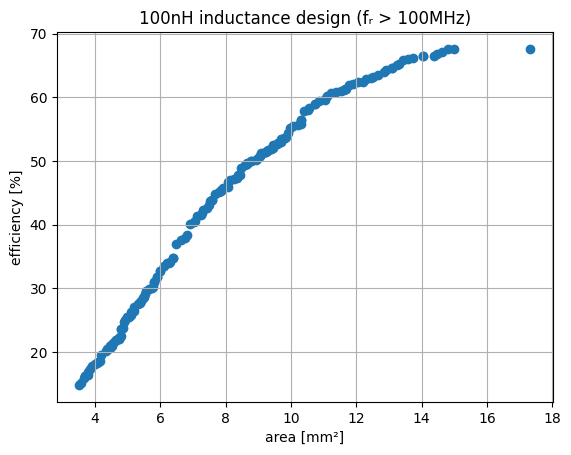

In [30]:
import matplotlib.pyplot as plt

# pymoo 결과 res에서 F를 꺼내 옵니다 (shape = [n_points, 2])
F = res.F
F = final_F

# 1열이 f1, 2열이 f2

plt.figure()

f1_vals = F[:, 0]
f2_vals = -F[:, 1]
plt.scatter(f1_vals, f2_vals)
plt.xlabel('area [mm²]')
plt.ylabel('efficiency [%]')
plt.title('100nH inductance design (fᵣ > 100MHz)')
plt.grid(True)
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# pymoo 결과 res에서 F를 꺼내 옵니다 (shape = [n_points, 2])
F = res.F

# 1열이 f1, 2열이 f2


plt.figure()

# f1_vals = df_1_3oz["area"]
# f2_vals = df_1_3oz["eff"]
# plt.scatter(f1_vals, f2_vals)

# f1_vals = df_1mil["area"]
# f2_vals = df_1mil["eff"]
# plt.scatter(f1_vals, f2_vals)

f1_vals = df_1oz["area"]
f2_vals = df_1oz["eff"]
plt.scatter(f1_vals, f2_vals)

f1_vals = df_1oz_v2["area"]
f2_vals = df_1oz_v2["eff"]
plt.scatter(f1_vals, f2_vals)

# f1_vals = df_2oz["area"]
# f2_vals = df_2oz["eff"]
# plt.scatter(f1_vals, f2_vals)

f1_vals = df_1mil["area"]
f2_vals = df_1mil["eff"]
plt.scatter(f1_vals, f2_vals)

plt.xlabel('area [mm²]')
plt.ylabel('efficiency [%]')
# plt.title('100nH inductance design (fᵣ > 100MHz)')
plt.grid(True)
plt.legend(["1oz (L/S=100um/100um)", "1oz (L/S=60um/60um)", "1mil (L/S=60um/60um)"])
plt.show()




In [ ]:
import matplotlib.pyplot as plt

# pymoo 결과 res에서 F를 꺼내 옵니다 (shape = [n_points, 2])
F = res.F

# 1열이 f1, 2열이 f2
f1_vals = df_sorted["S11_10M"]
f2_vals = df_sorted["LT_10M"]

plt.figure()
plt.scatter(f1_vals, f2_vals)
plt.xlabel('area [mm²]')
plt.ylabel('efficiency [%]')
plt.title('100nH inductance design (fᵣ > 100MHz)')
plt.grid(True)
plt.show()
